# Strongest Trend Graphs — Code Version with Fit Tests

This notebook keeps the editable code and adds multiple trend-fit tests to every plotted graph.

Each graph keeps the rolling mean as a solid black line and adds the best-fit curve as a dash-dot colored line. The fit tables compare linear, quadratic, cubic, logarithmic, inverse, and exponential decay fits using R², RMSE, and AIC.


## BLA — Frequency-domain relative power

In [1]:
# Source: ZBLA_global(1).ipynb, cell 1

# NumPy handles arrays, indexing, and mathematical operations.
import numpy as np

# Pandas stores trial-by-band tables and makes averaging easier.
import pandas as pd

# Matplotlib is used to make the figures.
import matplotlib.pyplot as plt

# These imports let us silence extra warnings / printouts from the helper functions.
import warnings
import contextlib
import io

# These project helper functions are already used elsewhere in your notebook.
# - load_eeg_data loads the epochs for one subject
# - compute_frequency_power computes frequency-domain band power per trial
from utils import load_eeg_data, compute_frequency_power

# Show plots directly inside the notebook.
%matplotlib inline

# Slightly increase default display quality so the plots are easier to read.
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})





In [2]:
# ------------------------------------------------------------
# HELPER FUNCTIONS: TEST MULTIPLE FIT TYPES AND PLOT BEST FIT
# ------------------------------------------------------------

from scipy.optimize import curve_fit
from IPython.display import display
import warnings

# Different model shapes to test.
def linear_model(x, a, b):
    return a * x + b

def quadratic_model(x, a, b, c):
    return a * x**2 + b * x + c

def cubic_model(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

def exp_decay_model(x, A, k, C):
    return A * np.exp(-k * x) + C

def log_model(x, a, b):
    return a * np.log(x) + b

def inverse_model(x, a, b):
    return a / x + b


def calculate_fit_stats(y_true, y_pred, num_params):
    """Calculate R², RMSE, and AIC for a fitted curve."""
    residuals = y_true - y_pred
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)

    if ss_tot == 0:
        r_squared = np.nan
    else:
        r_squared = 1 - (ss_res / ss_tot)

    rmse = np.sqrt(np.mean(residuals**2))
    n = len(y_true)

    # AIC: lower is better. It rewards better fit but penalizes extra parameters.
    if ss_res <= 0 or n == 0:
        aic = np.nan
    else:
        aic = n * np.log(ss_res / n) + 2 * num_params

    return r_squared, rmse, aic


def test_fit_models(trial_idx, values):
    """Try several curve shapes and return a list of fit results."""
    fit_results = []

    model_specs = [
        ("linear", linear_model, None),
        ("quadratic", quadratic_model, None),
        ("cubic", cubic_model, None),
        ("logarithmic", log_model, None),
        ("inverse", inverse_model, None),
    ]

    # Add exponential decay separately because it benefits from starting guesses.
    A_guess = values[0] - values[-1]
    k_guess = 0.10
    C_guess = values[-1]
    model_specs.append(("exponential decay", exp_decay_model, [A_guess, k_guess, C_guess]))

    for fit_name, model_func, p0 in model_specs:
        try:
            if p0 is None:
                params, _ = curve_fit(model_func, trial_idx, values, maxfev=10000)
            else:
                params, _ = curve_fit(model_func, trial_idx, values, p0=p0, maxfev=10000)

            fitted = model_func(trial_idx, *params)
            r2, rmse, aic = calculate_fit_stats(values, fitted, len(params))

            fit_results.append({
                "Fit type": fit_name,
                "params": params,
                "fitted": fitted,
                "R squared": r2,
                "RMSE": rmse,
                "AIC": aic,
            })

        except Exception:
            # Some fits may fail for some bands/ratios. That is okay.
            pass

    return fit_results


def add_best_fit_to_axis(ax, trial_idx, values, line_color, label_prefix, all_fit_results):
    """
    Test multiple fits, add the best one to the current axis, and save the results.

    Best fit is chosen by AIC.
    Lower AIC = better fit after penalizing extra curve complexity.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fit_results = test_fit_models(trial_idx, values)

    if len(fit_results) == 0:
        all_fit_results.append({
            "Graph": label_prefix,
            "Fit type": "no fit succeeded",
            "R squared": np.nan,
            "RMSE": np.nan,
            "AIC": np.nan,
            "Best by AIC": True,
        })
        return

    # Choose the best fit by AIC. Ignore nan AIC values unless all are nan.
    valid_results = [result for result in fit_results if not np.isnan(result["AIC"])]
    if len(valid_results) > 0:
        best_fit = min(valid_results, key=lambda result: result["AIC"])
    else:
        best_fit = max(fit_results, key=lambda result: result["R squared"])

    for result in fit_results:
        all_fit_results.append({
            "Graph": label_prefix,
            "Fit type": result["Fit type"],
            "R squared": result["R squared"],
            "RMSE": result["RMSE"],
            "AIC": result["AIC"],
            "Best by AIC": result["Fit type"] == best_fit["Fit type"],
        })

    # Unique-looking fit line: dash-dot pattern, while rolling mean remains solid black.
    ax.plot(
        trial_idx,
        best_fit["fitted"],
        color=line_color,
        linewidth=3,
        linestyle=(0, (6, 2, 1, 2)),
        zorder=4,
        label=f"Best fit: {best_fit['Fit type']}, R²={best_fit['R squared']:.2f}",
    )


def display_fit_table(all_fit_results, title="Fit comparison table"):
    """Display a clean table of all fits, with the best fit for each graph first."""
    fit_results_df = pd.DataFrame(all_fit_results)

    if len(fit_results_df) == 0:
        print(f"{title}: no fit results to display.")
        return fit_results_df

    fit_results_df = fit_results_df.sort_values(
        by=["Graph", "AIC"],
        ascending=[True, True]
    )

    print(title)
    display(fit_results_df)
    return fit_results_df






In [3]:
# Source: ZBLA_global(1).ipynb, cell 2

# These are the subjects used in your BLA analysis.
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]

# CONDITION tells the loader which task / dataset to open.
CONDITION = "BLA"

# CHANNELS tells the loader to use the BLA ROI channel group.
CHANNELS = "BLA"

# These are the frequency bands that will be plotted in the final figure.
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

# These colors are only for plotting so each band has a consistent visual identity.
colors = ['blue', 'green', 'red', 'orange', 'purple']

# The rolling window is only for the thick black trend line.
# It smooths the visual trend but does NOT alter the stored trial values.
ROLLING_WINDOW = 5

# This label is just text for titles / print statements so you remember
# what kind of baseline this notebook is using.
BASELINE_LABEL = "global average over all times and all trials"

print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")
print(f"Baseline definition: {BASELINE_LABEL}")





Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: BLA
Channels: BLA
Baseline definition: global average over all times and all trials


In [4]:
# Source: ZBLA_global(1).ipynb, cell 3

# These dictionaries store the trial-level outputs for each subject.
# all_power_pivots_raw[subject_id]
#     Raw absolute power for each trial and band before centering.
#
# all_global_baseline_pivots[subject_id]
#     One-row table containing the subject's across-trial mean power
#     for each band. This is the baseline that gets subtracted.
#
# all_power_pivots_centered[subject_id]
#     Raw trial power minus that subject's global band-wise baseline.
#
# all_psds_dicts[subject_id]
#     Extra PSD output returned by compute_frequency_power, saved in case
#     you want to inspect it later.
all_power_pivots_raw = {}
all_global_baseline_pivots = {}
all_power_pivots_centered = {}
all_psds_dicts = {}

# Keep track of which subjects processed successfully.
processed_subjects = []

# Keep track of failures so the notebook does not crash on one bad subject.
failed_subjects = []

# Loop over subjects one at a time so we can compute each subject's trial-level power.
for subject_id in SUBJECTS:
    try:
        # Silence extra warnings and console spam so the notebook output stays clean.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                # Load the epoched BLA data for this subject.
                epochs = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band="delta_gamma"
                )

                # Compute frequency-domain absolute power across the full epoch ("all times").
                # The helper returns:
                # - power_df: a long-format table with columns like trial, band, power
                # - psds_dict: extra PSD information saved for reference
                power_df, psds_dict = compute_frequency_power(epochs, fmin=0.5, fmax=45)

        # Convert the long-format power table into a trial x band matrix.
        #
        # groupby(['trial', 'band'])['power'].mean()
        #     If there are multiple rows per trial-band pair, average them first.
        #
        # unstack()
        #     Move the band labels out into separate columns.
        #
        # reindex(columns=bands)
        #     Force a consistent column order: delta, theta, alpha, beta, gamma.
        power_pivot_raw = (
            power_df.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        # Compute the global baseline for this subject.
        #
        # power_pivot_raw.mean(axis=0)
        #     Average DOWN the rows, so for each band we get one number:
        #     the mean power across ALL trials for that subject.
        #
        # This is the key change in this notebook.
        # We are NOT using a pre-stimulus crop anymore.
        # We are using the average full-epoch power across all trials.
        global_baseline = power_pivot_raw.mean(axis=0)

        # Turn that Series into a 1-row DataFrame so it is easy to inspect later.
        # The single row represents the subject's band-wise baseline values.
        global_baseline_pivot = pd.DataFrame([global_baseline], columns=bands)

        # Center each trial by subtracting the same band-specific baseline value.
        #
        # Because pandas aligns by column name, each trial's delta value gets
        # delta's baseline subtracted, alpha gets alpha's baseline subtracted, etc.
        power_pivot_centered = power_pivot_raw - global_baseline

        # Save everything for later plotting.
        all_power_pivots_raw[subject_id] = power_pivot_raw
        all_global_baseline_pivots[subject_id] = global_baseline_pivot
        all_power_pivots_centered[subject_id] = power_pivot_centered
        all_psds_dicts[subject_id] = psds_dict

        # Record that this subject finished successfully.
        processed_subjects.append(subject_id)

    except Exception as e:
        # Save the error message rather than stopping the whole notebook.
        failed_subjects.append((subject_id, str(e)))

print("Processed successfully:", processed_subjects)

if failed_subjects:
    print("\nFailed:")
    for subject_id, err in failed_subjects:
        print(f"Subject {subject_id}: {err}")





Processed successfully: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


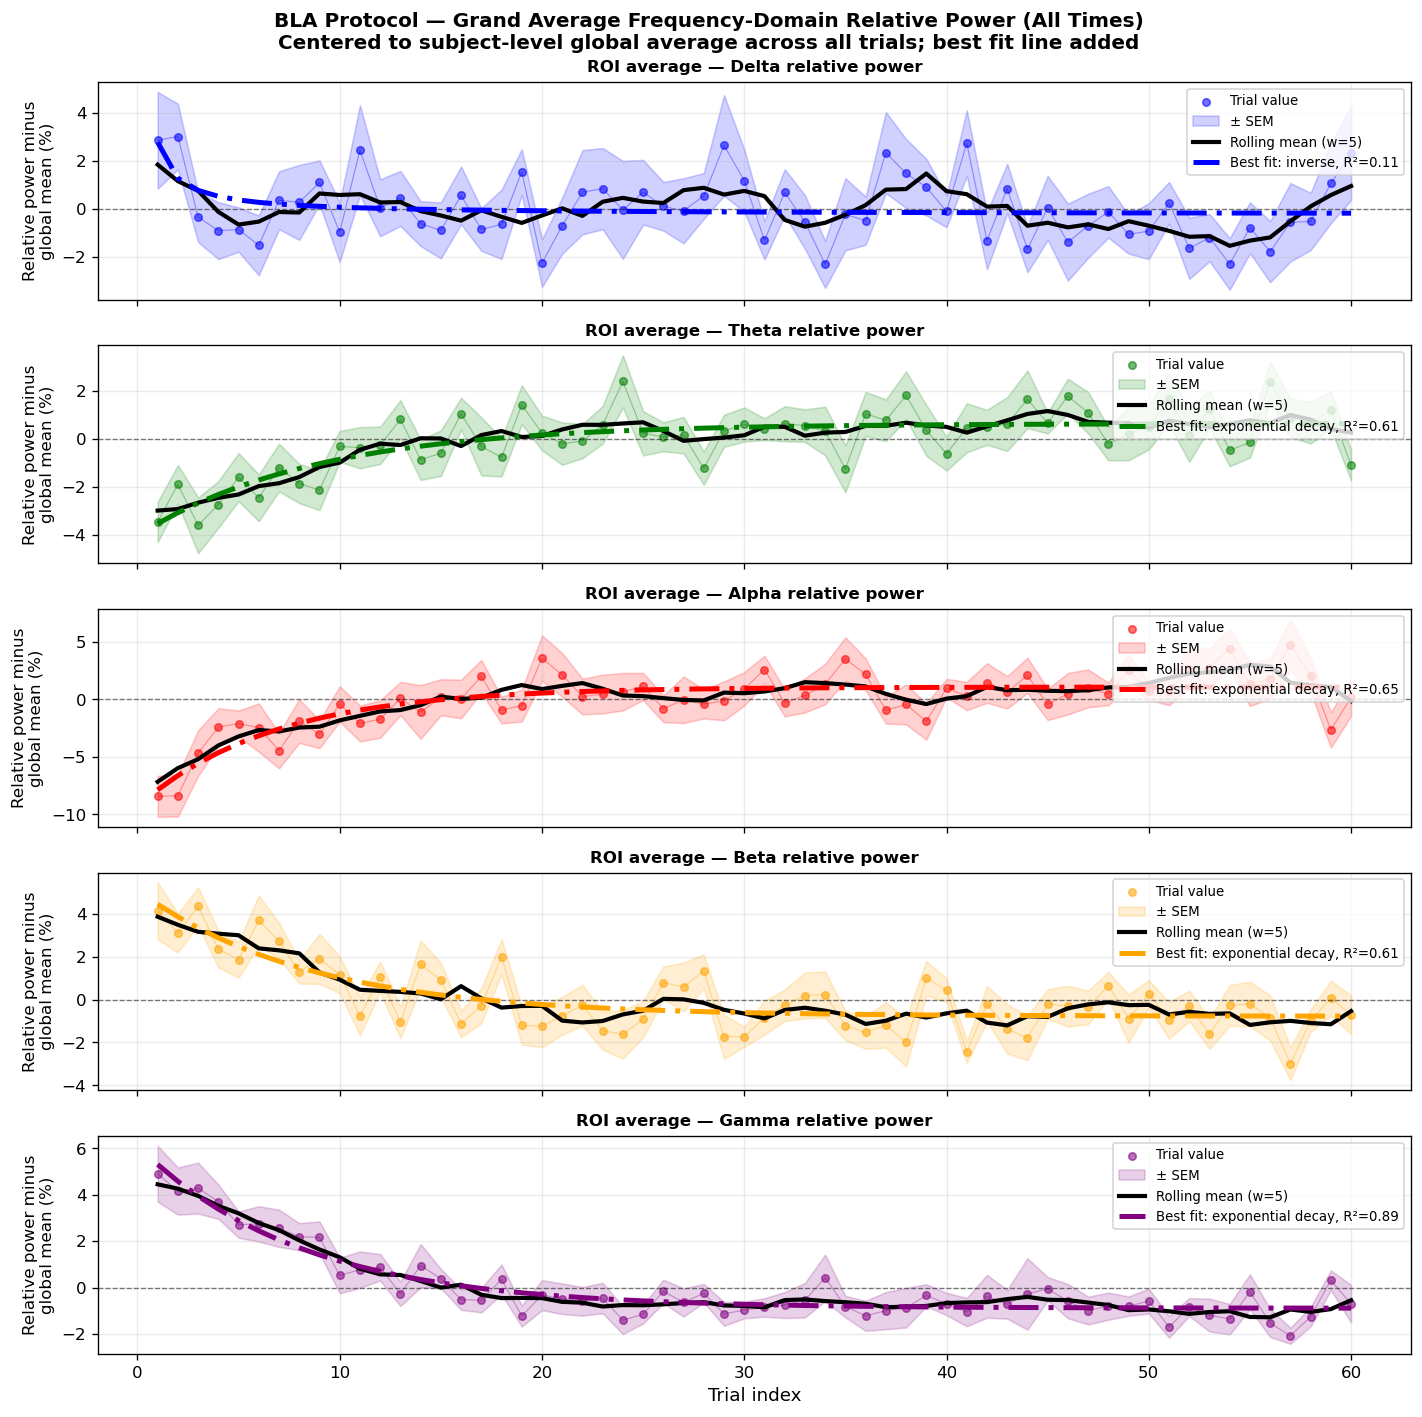

Figure saved: frequency_relative_dynamics_BLA_global_mean_centered.png
BLA frequency-domain relative power fit comparison


,Graph,Fit type,R squared,RMSE,AIC,Best by AIC
17,BLA relative power — alpha,exponential decay,0.653666,1.455836,51.069648,True
15,BLA relative power — alpha,logarithmic,0.618358,1.528245,54.894431,False
14,BLA relative power — alpha,cubic,0.623104,1.518713,58.143592,False
16,BLA relative power — alpha,inverse,0.558311,1.644080,63.661706,False
13,BLA relative power — alpha,quadratic,0.542480,1.673285,67.774653,False
12,BLA relative power — alpha,linear,0.391450,1.929802,82.890115,False
23,BLA relative power — beta,exponential decay,0.614877,0.982827,3.921335,True
20,BLA relative power — beta,cubic,0.618413,0.978304,5.367856,False
21,BLA relative power — beta,logarithmic,0.559460,1.051164,9.987735,False
19,BLA relative power — beta,quadratic,0.551674,1.060411,13.038842,False


In [5]:
# Source: ZBLA_global(1).ipynb, cell 10
# ------------------------------------------------------------
# FREQUENCY-DOMAIN RELATIVE POWER (all times)
# centered to a subject-level global relative-power mean
# ------------------------------------------------------------

# These dictionaries will store, for each subject:
# 1) the raw relative power for each trial and band
# 2) the one-row global baseline that gets subtracted
# 3) the centered relative power after subtracting that baseline
all_relative_power_pivots_raw = {}
all_relative_global_baseline_pivots = {}
all_relative_power_pivots_centered = {}

# Loop over each subject that already successfully completed
# the raw frequency-domain absolute-power section above.
for subject_id in processed_subjects:

    # Start from the raw absolute power table:
    # rows = trials
    # columns = bands
    power_pivot_raw = all_power_pivots_raw[subject_id].copy()

    # Force the same band order for every subject so later
    # averaging lines up delta with delta, alpha with alpha, etc.
    power_pivot_raw = power_pivot_raw.reindex(columns=bands)

    # For each trial, total power is the sum across all bands.
    # axis=1 means sum across columns within each row.
    total_power_per_trial = power_pivot_raw.sum(axis=1)

    # Convert absolute power into relative power:
    # each band becomes its percentage of that trial's total power.
    relative_power_raw = power_pivot_raw.div(total_power_per_trial, axis=0) * 100

    # Compute one subject-level global baseline for each band.
    # This is the mean relative power across all trials for that band.
    relative_global_baseline = relative_power_raw.mean(axis=0)

    # Save the baseline as a one-row DataFrame so you can inspect it later.
    relative_global_baseline_pivot = pd.DataFrame([relative_global_baseline], columns=bands)

    # Subtract the same baseline value from every trial in that band.
    # After this step:
    #   0  = equal to subject's average relative power for that band
    #   >0 = above average
    #   <0 = below average
    relative_power_centered = relative_power_raw - relative_global_baseline

    # Store everything.
    all_relative_power_pivots_raw[subject_id] = relative_power_raw
    all_relative_global_baseline_pivots[subject_id] = relative_global_baseline_pivot
    all_relative_power_pivots_centered[subject_id] = relative_power_centered

# These will hold the grand mean and SEM across subjects for each band.
grand_relative_power = {}
grand_relative_sem = {}

# Build one grand-average trial series per band.
for band in bands:

    # Collect one subject vector per band.
    band_trials = []

    for subject_id in processed_subjects:
        relative_pivot = all_relative_power_pivots_centered[subject_id]

        if band in relative_pivot.columns:
            # reset_index(drop=True) makes trial positions line up cleanly
            # when subjects are concatenated side by side.
            band_trials.append(relative_pivot[band].reset_index(drop=True))

    if band_trials:
        band_df = pd.concat(band_trials, axis=1)
        grand_relative_power[band] = band_df.mean(axis=1)
        grand_relative_sem[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

# Store fit-comparison results for each band in this graph.
all_fit_results = []

# Plot one subplot per band.
fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    if band in grand_relative_power:
        values = grand_relative_power[band].values
        errors = grand_relative_sem[band].values
        trial_idx = np.arange(1, len(values) + 1)

        # Trial-by-trial grand mean
        ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

        # Uncertainty shading
        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM'
        )

        # Rolling trend line to make the overall direction easier to see
        rolling = pd.Series(values).rolling(
            window=ROLLING_WINDOW,
            center=True,
            min_periods=1
        ).mean()

        ax.plot(
            trial_idx,
            rolling,
            color='black',
            linewidth=2.5,
            zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})'
        )

        # Test multiple fit types and add the best fit line.
        # The rolling mean stays black; the best fit uses a dash-dot colored line.
        add_best_fit_to_axis(
            ax=ax,
            trial_idx=trial_idx,
            values=values,
            line_color=color,
            label_prefix=f"{CONDITION} relative power — {band}",
            all_fit_results=all_fit_results
        )

    ax.set_ylabel('Relative power minus\nglobal mean (%)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} relative power', fontsize=10, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.25)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Trial index', fontsize=11)

fig.suptitle(
    'BLA Protocol — Grand Average Frequency-Domain Relative Power (All Times)\n'
    'Centered to subject-level global average across all trials; best fit line added',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('frequency_relative_dynamics_BLA_global_mean_centered.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: frequency_relative_dynamics_BLA_global_mean_centered.png")

# Show the fit-comparison table for this figure.
fit_results_df = display_fit_table(
    all_fit_results,
    title=f"{CONDITION} frequency-domain relative power fit comparison"
)






## BLA — Band ratios

In [6]:
# Source: ZBLA_ratio(1).ipynb, cell 2

# These are the subjects used in your BLA analysis.
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]

# CONDITION tells the loader which task / dataset to open.
CONDITION = "BLA"

# CHANNELS tells the loader to use the BLA ROI channel group.
CHANNELS = "BLA"

# These are the frequency bands that will be plotted in the final figure.
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

# These colors are only for plotting so each band has a consistent visual identity.
colors = ['blue', 'green', 'red', 'orange', 'purple']

# The rolling window is only for the thick black trend line.
# It smooths the visual trend but does NOT alter the stored trial values.
ROLLING_WINDOW = 5

# This label is just text for titles / print statements so you remember
# what kind of baseline this notebook is using.
BASELINE_LABEL = "global average over all times and all trials"

print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")
print(f"Baseline definition: {BASELINE_LABEL}")


# ------------------------------------------------------------
# BAND RATIO SETTINGS
# ------------------------------------------------------------

# Each tuple is written as:
#     ('numerator_band', 'denominator_band')
#
# Example:
#     ('theta', 'alpha') means theta power divided by alpha power.
#
# You can edit this list if you want different pairs.
BAND_RATIO_PAIRS = [
    ('theta', 'delta'),
    ('alpha', 'theta'),
    ('beta', 'alpha'),
    ('gamma', 'beta'),
    ('theta', 'beta'),
    ('gamma', 'theta'),
    ('gamma', 'alpha')
]

# These labels will be used on the plots.
ratio_labels = [f"{num}/{den}" for num, den in BAND_RATIO_PAIRS]

# Colors for ratio plots. If there are more ratios than colors, the list repeats.
ratio_colors = [
    'blue',
    'green',
    'red',
    'orange',
    'purple',
    'brown',
    'pink',
    'gray',
    'olive',
    'cyan'
]

print("Band ratio pairs:")
for pair in BAND_RATIO_PAIRS:
    print(f"  {pair[0]} / {pair[1]}")





Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: BLA
Channels: BLA
Baseline definition: global average over all times and all trials
Band ratio pairs:
  theta / delta
  alpha / theta
  beta / alpha
  gamma / beta
  theta / beta
  gamma / theta
  gamma / alpha


In [7]:
# Source: ZBLA_ratio(1).ipynb, cell 3

# ------------------------------------------------------------
# HELPER FUNCTION: COMPUTE CENTERED BAND RATIOS
# ------------------------------------------------------------

def compute_centered_band_ratios_for_window(window_name, tmin=None, tmax=None):
    """
    Computes centered frequency-band ratios for one time window.

    Parameters
    ----------
    window_name : str
        Text label for the window, such as "all_times", "0_500", or "500_1000".

    tmin : float or None
        Start time in seconds.
        Use None to keep the original beginning of the epoch.

    tmax : float or None
        End time in seconds.
        Use None to keep the original end of the epoch.

    Returns
    -------
    results : dict
        A dictionary containing raw ratio tables, baseline ratio tables,
        centered ratio tables, grand averages, SEMs, processed subjects,
        and failed subjects.
    """

    # These dictionaries store subject-level results.
    all_power_pivots_raw = {}
    all_ratio_pivots_raw = {}
    all_ratio_baseline_pivots = {}
    all_ratio_pivots_centered = {}
    all_psds_dicts = {}

    processed_subjects_window = []
    failed_subjects_window = []

    # Loop through each subject.
    for subject_id in SUBJECTS:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                    # Load the same BLA epochs as the original notebook.
                    epochs = load_eeg_data(
                        CONDITION,
                        subject_id,
                        channels=CHANNELS,
                        freq_band="delta_gamma"
                    )

                    # Crop only if a time window was given.
                    # MNE uses seconds, so:
                    #   0–500 ms      = tmin=0.0, tmax=0.5
                    #   500–1000 ms   = tmin=0.5, tmax=1.0
                    if tmin is not None or tmax is not None:
                        epochs_for_ratio = epochs.copy().crop(tmin=tmin, tmax=tmax)
                    else:
                        epochs_for_ratio = epochs.copy()

                    # Compute frequency-domain absolute power using the same helper function.
                    power_df, psds_dict = compute_frequency_power(
                        epochs_for_ratio,
                        fmin=0.5,
                        fmax=45
                    )

            # Convert long-format power output into trial x band format.
            power_pivot_raw = (
                power_df.groupby(['trial', 'band'])['power']
                .mean()
                .unstack()
                .reindex(columns=bands)
            )

            # This table will hold ratio values for each trial.
            ratio_pivot_raw = pd.DataFrame(index=power_pivot_raw.index)

            # Compute each requested band ratio.
            for numerator_band, denominator_band in BAND_RATIO_PAIRS:

                ratio_name = f"{numerator_band}/{denominator_band}"

                # Make sure both bands exist before computing the ratio.
                if numerator_band in power_pivot_raw.columns and denominator_band in power_pivot_raw.columns:

                    # Ratio = power in numerator band / power in denominator band.
                    ratio_pivot_raw[ratio_name] = (
                        power_pivot_raw[numerator_band] / power_pivot_raw[denominator_band]
                    )

                else:
                    # If a band is missing, fill with NaN so the notebook does not crash.
                    ratio_pivot_raw[ratio_name] = np.nan

            # Replace infinite values with NaN, just in case a denominator is zero.
            ratio_pivot_raw = ratio_pivot_raw.replace([np.inf, -np.inf], np.nan)

            # Compute this subject's global mean ratio across all trials.
            ratio_global_baseline = ratio_pivot_raw.mean(axis=0)

            # Center each trial by subtracting this subject's global mean ratio.
            ratio_pivot_centered = ratio_pivot_raw - ratio_global_baseline

            # Store subject-level outputs.
            all_power_pivots_raw[subject_id] = power_pivot_raw
            all_ratio_pivots_raw[subject_id] = ratio_pivot_raw
            all_ratio_baseline_pivots[subject_id] = pd.DataFrame(
                [ratio_global_baseline],
                columns=ratio_pivot_raw.columns
            )
            all_ratio_pivots_centered[subject_id] = ratio_pivot_centered
            all_psds_dicts[subject_id] = psds_dict

            processed_subjects_window.append(subject_id)

        except Exception as e:
            failed_subjects_window.append((subject_id, str(e)))

    print(f"{window_name} ratio subjects processed:", processed_subjects_window)

    if failed_subjects_window:
        print(f"\n{window_name} ratio failures:")
        for subject_id, err in failed_subjects_window:
            print(f"Subject {subject_id}: {err}")

    # Grand average across subjects.
    grand_ratio = {}
    grand_ratio_sem = {}

    for ratio_name in ratio_labels:
        ratio_trials = []

        for subject_id in processed_subjects_window:
            ratio_pivot = all_ratio_pivots_centered[subject_id]

            if ratio_name in ratio_pivot.columns:
                ratio_trials.append(ratio_pivot[ratio_name].reset_index(drop=True))

        if ratio_trials:
            ratio_df = pd.concat(ratio_trials, axis=1)

            # Mean across subjects at each trial index.
            grand_ratio[ratio_name] = ratio_df.mean(axis=1)

            # SEM across subjects at each trial index.
            grand_ratio_sem[ratio_name] = ratio_df.std(axis=1) / np.sqrt(ratio_df.shape[1])

    return {
        "window_name": window_name,
        "tmin": tmin,
        "tmax": tmax,
        "all_power_pivots_raw": all_power_pivots_raw,
        "all_ratio_pivots_raw": all_ratio_pivots_raw,
        "all_ratio_baseline_pivots": all_ratio_baseline_pivots,
        "all_ratio_pivots_centered": all_ratio_pivots_centered,
        "all_psds_dicts": all_psds_dicts,
        "processed_subjects": processed_subjects_window,
        "failed_subjects": failed_subjects_window,
        "grand_ratio": grand_ratio,
        "grand_ratio_sem": grand_ratio_sem
    }


# ------------------------------------------------------------
# HELPER FUNCTION: PLOT CENTERED BAND RATIOS
# ------------------------------------------------------------

def plot_centered_band_ratios(results, title_label, save_filename):
    """
    Plots the grand-average centered ratio values for one time window.
    Adds rolling mean in black and tests multiple fit types for each ratio.
    """

    grand_ratio = results["grand_ratio"]
    grand_ratio_sem = results["grand_ratio_sem"]

    # Store fit-comparison results for each ratio in this graph.
    all_fit_results = []

    # Create one subplot per ratio.
    fig, axes = plt.subplots(len(ratio_labels), 1, figsize=(12, 2.5 * len(ratio_labels)), sharex=True)

    # If there is only one ratio, axes is not automatically a list.
    if len(ratio_labels) == 1:
        axes = [axes]

    for i, ratio_name in enumerate(ratio_labels):
        ax = axes[i]
        color = ratio_colors[i % len(ratio_colors)]

        if ratio_name in grand_ratio:
            values = grand_ratio[ratio_name].values
            errors = grand_ratio_sem[ratio_name].values
            trial_idx = np.arange(1, len(values) + 1)

            ax.scatter(
                trial_idx,
                values,
                color=color,
                s=20,
                alpha=0.55,
                zorder=2,
                label='Trial value'
            )

            ax.plot(
                trial_idx,
                values,
                color=color,
                linewidth=0.7,
                alpha=0.35,
                zorder=1
            )

            ax.fill_between(
                trial_idx,
                values - errors,
                values + errors,
                color=color,
                alpha=0.18,
                zorder=1,
                label='± SEM'
            )

            # Rolling mean stays black.
            rolling = pd.Series(values).rolling(
                window=ROLLING_WINDOW,
                center=True,
                min_periods=1
            ).mean()

            ax.plot(
                trial_idx,
                rolling,
                color='black',
                linewidth=2.5,
                zorder=3,
                label=f'Rolling mean (w={ROLLING_WINDOW})'
            )

            # Test multiple fit types and add the best fit line.
            # The fit line is dash-dot so it looks different from the rolling mean.
            add_best_fit_to_axis(
                ax=ax,
                trial_idx=trial_idx,
                values=values,
                line_color=color,
                label_prefix=f"{CONDITION} ratio — {ratio_name} ({title_label})",
                all_fit_results=all_fit_results
            )

        ax.set_ylabel('Ratio minus\nglobal mean', fontsize=10)

        ax.set_title(
            f'ROI average — {ratio_name} ratio, {title_label}',
            fontsize=10,
            fontweight='bold'
        )

        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.25)
        ax.legend(loc='upper right', fontsize=8)

    axes[-1].set_xlabel('Trial index', fontsize=11)

    fig.suptitle(
        f'BLA Protocol — Grand Average Frequency-Domain Band Ratios, {title_label}\n'
        f'Centered to subject-level global ratio average; best fit line added',
        fontsize=12,
        fontweight='bold'
    )

    fig.tight_layout()
    plt.savefig(save_filename, bbox_inches='tight', dpi=150)
    plt.show()

    print(f"Figure saved: {save_filename}")

    # Show the fit-comparison table for this ratio figure.
    fit_results_df = display_fit_table(
        all_fit_results,
        title=f"BLA band-ratio fit comparison — {title_label}"
    )

    return fit_results_df






all_times ratio subjects processed: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


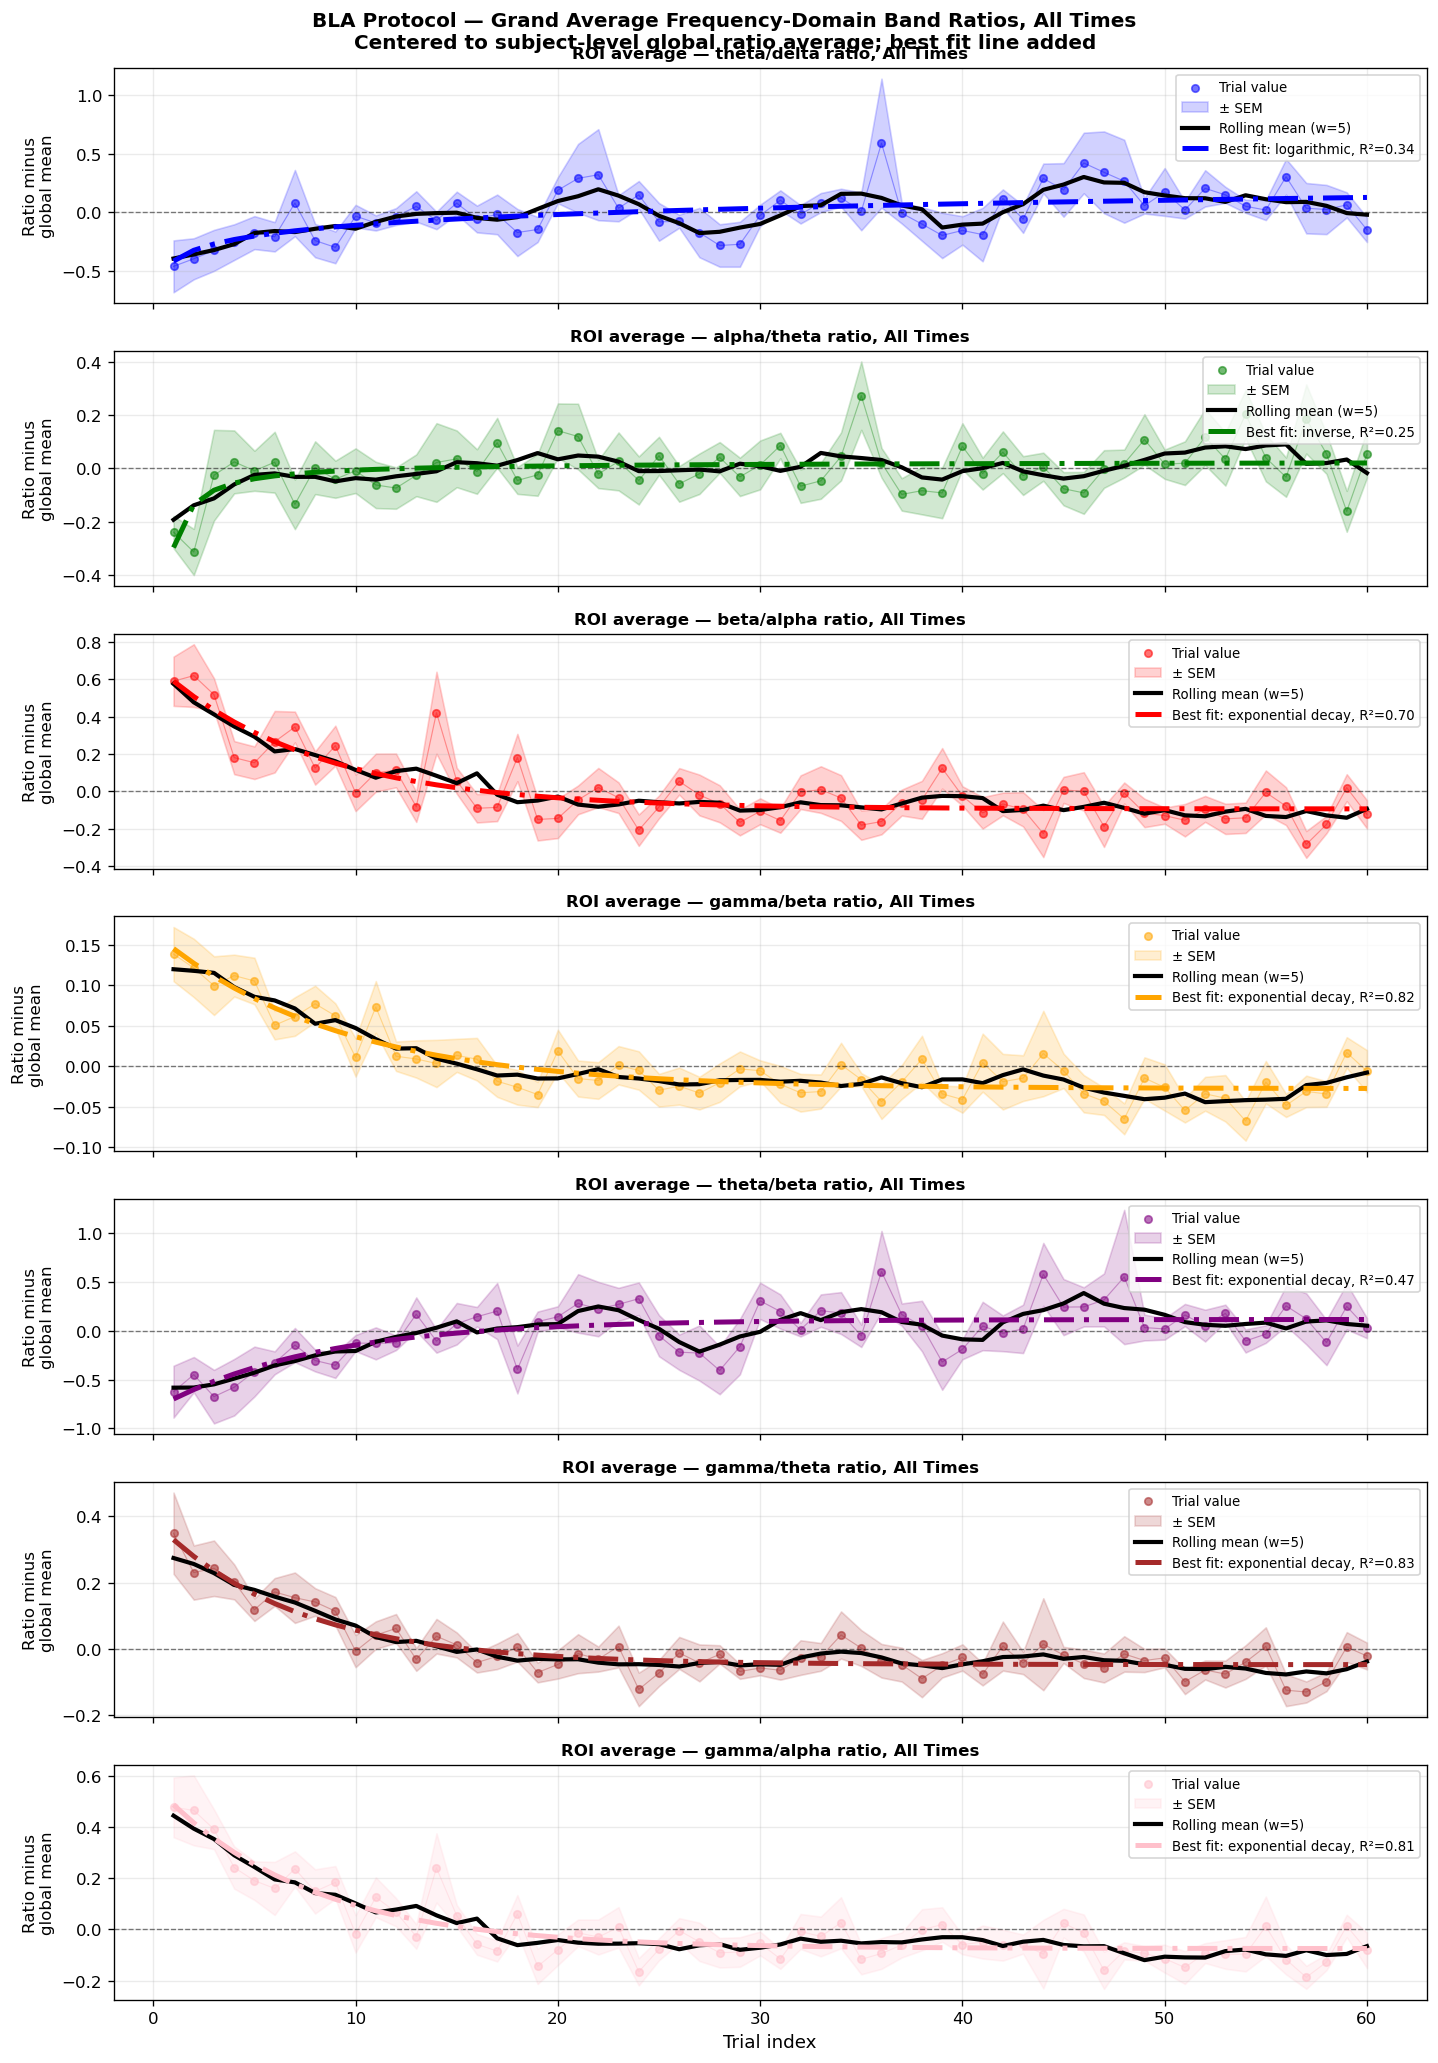

Figure saved: BLA_band_ratios_all_times_global_mean_centered.png
BLA band-ratio fit comparison — All Times


,Graph,Fit type,R squared,RMSE,AIC,Best by AIC
10,BLA ratio — alpha/theta (All Times),inverse,0.249624,0.081098,-297.452106,True
11,BLA ratio — alpha/theta (All Times),exponential decay,0.251857,0.080977,-295.630911,False
9,BLA ratio — alpha/theta (All Times),logarithmic,0.196813,0.083903,-293.371296,False
8,BLA ratio — alpha/theta (All Times),cubic,0.205684,0.083438,-290.037664,False
7,BLA ratio — alpha/theta (All Times),quadratic,0.141123,0.086763,-287.349045,False
6,BLA ratio — alpha/theta (All Times),linear,0.106509,0.088494,-286.978401,False
17,BLA ratio — beta/alpha (All Times),exponential decay,0.701268,0.104472,-265.059782,True
14,BLA ratio — beta/alpha (All Times),cubic,0.689145,0.106571,-260.672954,False
15,BLA ratio — beta/alpha (All Times),logarithmic,0.664783,0.110669,-260.145820,False
13,BLA ratio — beta/alpha (All Times),quadratic,0.611652,0.119116,-249.318449,False


,Graph,Fit type,R squared,RMSE,AIC,Best by AIC
10,BLA ratio — alpha/theta (All Times),inverse,0.249624,0.081098,-297.452106,True
11,BLA ratio — alpha/theta (All Times),exponential decay,0.251857,0.080977,-295.630911,False
9,BLA ratio — alpha/theta (All Times),logarithmic,0.196813,0.083903,-293.371296,False
8,BLA ratio — alpha/theta (All Times),cubic,0.205684,0.083438,-290.037664,False
7,BLA ratio — alpha/theta (All Times),quadratic,0.141123,0.086763,-287.349045,False
6,BLA ratio — alpha/theta (All Times),linear,0.106509,0.088494,-286.978401,False
17,BLA ratio — beta/alpha (All Times),exponential decay,0.701268,0.104472,-265.059782,True
14,BLA ratio — beta/alpha (All Times),cubic,0.689145,0.106571,-260.672954,False
15,BLA ratio — beta/alpha (All Times),logarithmic,0.664783,0.110669,-260.145820,False
13,BLA ratio — beta/alpha (All Times),quadratic,0.611652,0.119116,-249.318449,False


In [8]:
# Source: ZBLA_ratio(1).ipynb, cell 4

# ------------------------------------------------------------
# BAND RATIOS — ALL TIMES
# ------------------------------------------------------------

ratio_results_all_times = compute_centered_band_ratios_for_window(
    window_name="all_times",
    tmin=None,
    tmax=None
)

plot_centered_band_ratios(
    results=ratio_results_all_times,
    title_label="All Times",
    save_filename="BLA_band_ratios_all_times_global_mean_centered.png"
)





## BLT — Frequency-domain relative power

In [9]:
# Source: ZBLT_global(3).ipynb, cell 1

# NumPy handles arrays, indexing, and mathematical operations.
import numpy as np

# Pandas stores trial-by-band tables and makes averaging easier.
import pandas as pd

# Matplotlib is used to make the figures.
import matplotlib.pyplot as plt

# These imports let us silence extra warnings / printouts from the helper functions.
import warnings
import contextlib
import io

# These project helper functions are already used elsewhere in your notebook.
# - load_eeg_data loads the epochs for one subject
# - compute_frequency_power computes frequency-domain band power per trial
from utils import load_eeg_data, compute_frequency_power

# Show plots directly inside the notebook.
%matplotlib inline

# Slightly increase default display quality so the plots are easier to read.
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})





In [10]:
# Source: ZBLT_global(3).ipynb, cell 2

# These are the subjects used in your BLT analysis.
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]

# CONDITION tells the loader which task / dataset to open.
CONDITION = "BLT"

# CHANNELS tells the loader to use the BLT ROI channel group.
CHANNELS = "BLT"

# These are the frequency bands that will be plotted in the final figure.
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

# These colors are only for plotting so each band has a consistent visual identity.
colors = ['blue', 'green', 'red', 'orange', 'purple']

# The rolling window is only for the thick black trend line.
# It smooths the visual trend but does NOT alter the stored trial values.
ROLLING_WINDOW = 5

# This label is just text for titles / print statements so you remember
# what kind of baseline this notebook is using.
BASELINE_LABEL = "global average over all times and all trials"

print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")
print(f"Baseline definition: {BASELINE_LABEL}")





Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: BLT
Channels: BLT
Baseline definition: global average over all times and all trials


In [11]:
# Source: ZBLT_global(3).ipynb, cell 3
# Safety imports so this cell still works if the import cell was not run first.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import contextlib
import io
from utils import load_eeg_data, compute_frequency_power


# These dictionaries store the trial-level outputs for each subject.
# all_power_pivots_raw[subject_id]
#     Raw absolute power for each trial and band before centering.
#
# all_global_baseline_pivots[subject_id]
#     One-row table containing the subject's across-trial mean power
#     for each band. This is the baseline that gets subtracted.
#
# all_power_pivots_centered[subject_id]
#     Raw trial power minus that subject's global band-wise baseline.
#
# all_psds_dicts[subject_id]
#     Extra PSD output returned by compute_frequency_power, saved in case
#     you want to inspect it later.
all_power_pivots_raw = {}
all_global_baseline_pivots = {}
all_power_pivots_centered = {}
all_psds_dicts = {}

# Keep track of which subjects processed successfully.
processed_subjects = []

# Keep track of failures so the notebook does not crash on one bad subject.
failed_subjects = []

# Loop over subjects one at a time so we can compute each subject's trial-level power.
for subject_id in SUBJECTS:
    try:
        # Silence extra warnings and console spam so the notebook output stays clean.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                # Load the epoched BLT data for this subject.
                epochs = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band="delta_gamma"
                )

                # Compute frequency-domain absolute power across the full epoch ("all times").
                # The helper returns:
                # - power_df: a long-format table with columns like trial, band, power
                # - psds_dict: extra PSD information saved for reference
                power_df, psds_dict = compute_frequency_power(epochs, fmin=0.5, fmax=45)

        # Convert the long-format power table into a trial x band matrix.
        #
        # groupby(['trial', 'band'])['power'].mean()
        #     If there are multiple rows per trial-band pair, average them first.
        #
        # unstack()
        #     Move the band labels out into separate columns.
        #
        # reindex(columns=bands)
        #     Force a consistent column order: delta, theta, alpha, beta, gamma.
        power_pivot_raw = (
            power_df.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        # Compute the global baseline for this subject.
        #
        # power_pivot_raw.mean(axis=0)
        #     Average DOWN the rows, so for each band we get one number:
        #     the mean power across ALL trials for that subject.
        #
        # This is the key change in this notebook.
        # We are NOT using a pre-stimulus crop anymore.
        # We are using the average full-epoch power across all trials.
        global_baseline = power_pivot_raw.mean(axis=0)

        # Turn that Series into a 1-row DataFrame so it is easy to inspect later.
        # The single row represents the subject's band-wise baseline values.
        global_baseline_pivot = pd.DataFrame([global_baseline], columns=bands)

        # Center each trial by subtracting the same band-specific baseline value.
        #
        # Because pandas aligns by column name, each trial's delta value gets
        # delta's baseline subtracted, alpha gets alpha's baseline subtracted, etc.
        power_pivot_centered = power_pivot_raw - global_baseline

        # Save everything for later plotting.
        all_power_pivots_raw[subject_id] = power_pivot_raw
        all_global_baseline_pivots[subject_id] = global_baseline_pivot
        all_power_pivots_centered[subject_id] = power_pivot_centered
        all_psds_dicts[subject_id] = psds_dict

        # Record that this subject finished successfully.
        processed_subjects.append(subject_id)

    except Exception as e:
        # Save the error message rather than stopping the whole notebook.
        failed_subjects.append((subject_id, str(e)))

print("Processed successfully:", processed_subjects)

if failed_subjects:
    print("\nFailed:")
    for subject_id, err in failed_subjects:
        print(f"Subject {subject_id}: {err}")





Processed successfully: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


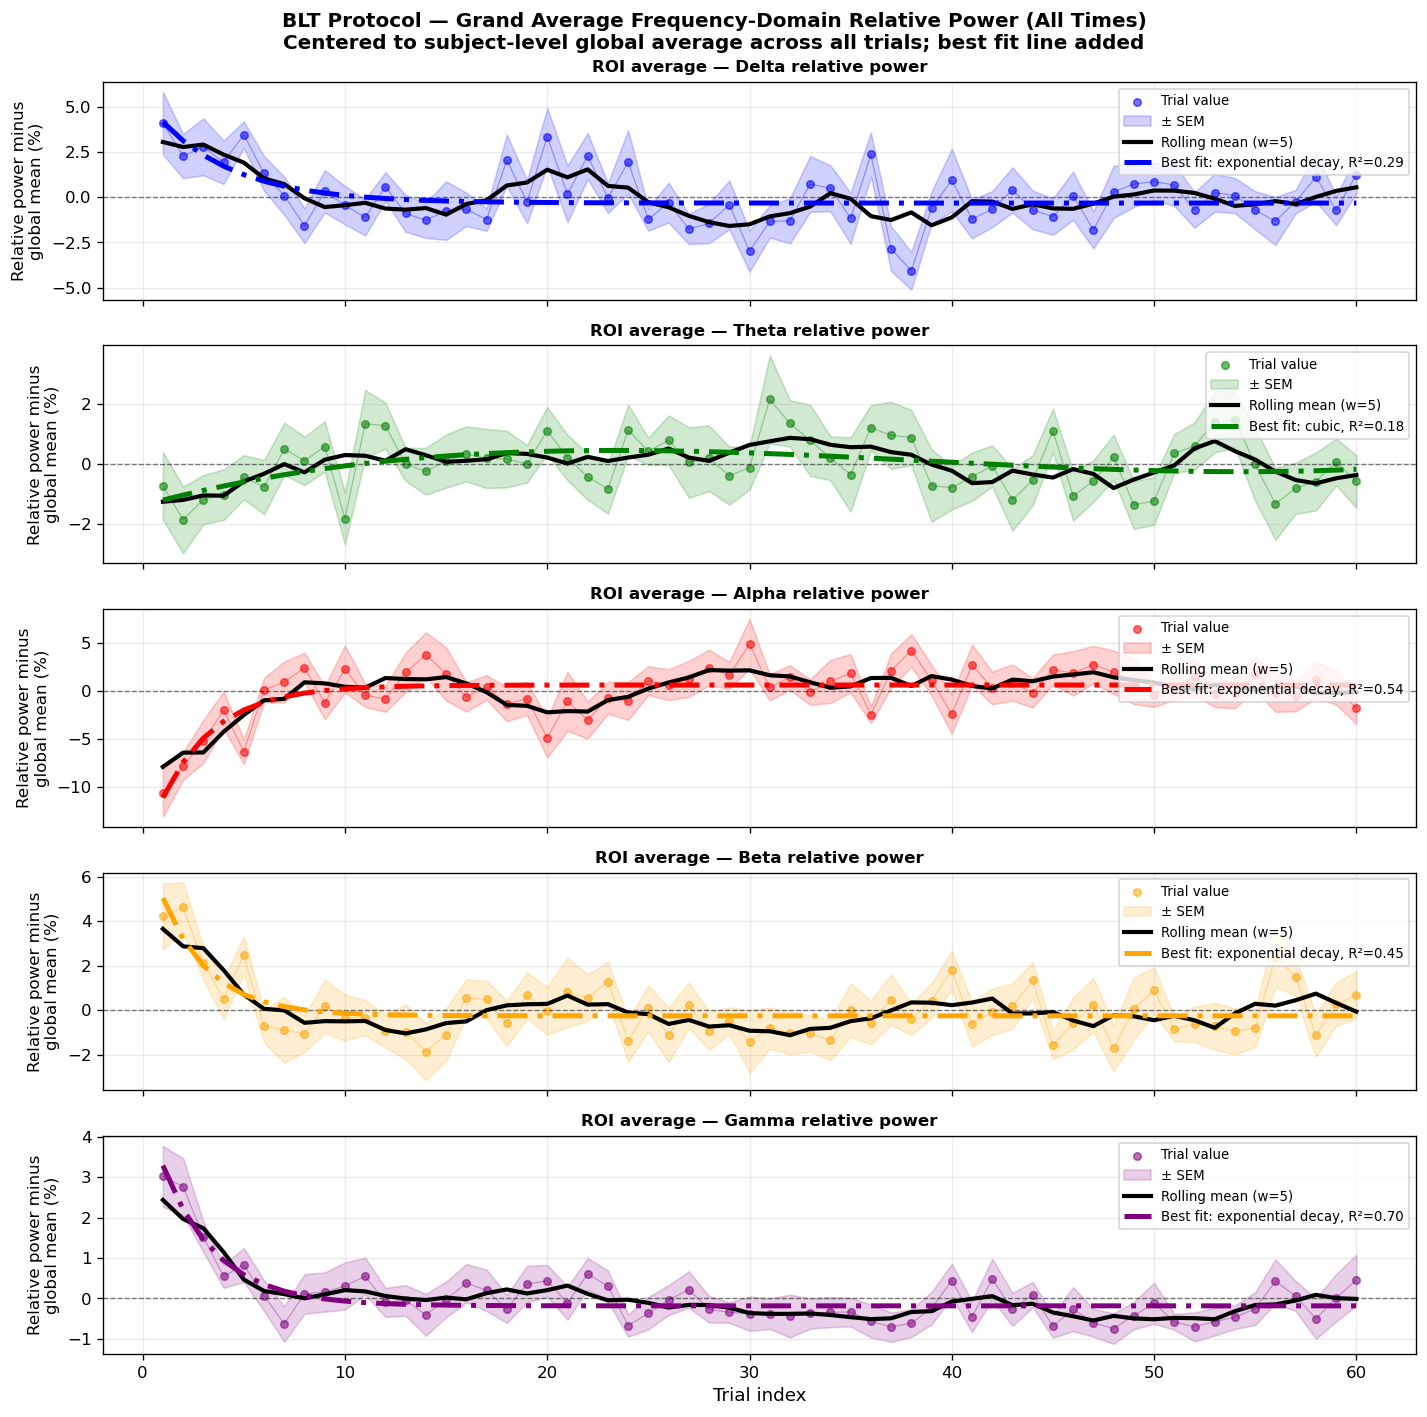

Figure saved: frequency_relative_dynamics_BLT_global_mean_centered.png
BLT frequency-domain relative power fit comparison


,Graph,Fit type,R squared,RMSE,AIC,Best by AIC
17,BLT relative power — alpha,exponential decay,0.541198,1.827384,78.346239,True
16,BLT relative power — alpha,inverse,0.508003,1.892336,80.537435,False
15,BLT relative power — alpha,logarithmic,0.355277,2.166225,96.758322,False
14,BLT relative power — alpha,cubic,0.365763,2.148537,99.774430,False
13,BLT relative power — alpha,quadratic,0.329388,2.209291,101.120573,False
12,BLT relative power — alpha,linear,0.144155,2.495829,113.754500,False
23,BLT relative power — beta,exponential decay,0.449345,0.958669,0.934873,True
22,BLT relative power — beta,inverse,0.380222,1.017061,6.030028,False
20,BLT relative power — beta,cubic,0.290045,1.088540,18.180468,False
21,BLT relative power — beta,logarithmic,0.192273,1.161077,21.921769,False


In [12]:
# Source: ZBLT_global(3).ipynb, cell 11
# ------------------------------------------------------------
# FREQUENCY-DOMAIN RELATIVE POWER (all times)
# centered to a subject-level global relative-power mean
# ------------------------------------------------------------

# These dictionaries will store, for each subject:
# 1) the raw relative power for each trial and band
# 2) the one-row global baseline that gets subtracted
# 3) the centered relative power after subtracting that baseline
all_relative_power_pivots_raw = {}
all_relative_global_baseline_pivots = {}
all_relative_power_pivots_centered = {}

# Loop over each subject that already successfully completed
# the raw frequency-domain absolute-power section above.
for subject_id in processed_subjects:

    # Start from the raw absolute power table:
    # rows = trials
    # columns = bands
    power_pivot_raw = all_power_pivots_raw[subject_id].copy()

    # Force the same band order for every subject so later
    # averaging lines up delta with delta, alpha with alpha, etc.
    power_pivot_raw = power_pivot_raw.reindex(columns=bands)

    # For each trial, total power is the sum across all bands.
    # axis=1 means sum across columns within each row.
    total_power_per_trial = power_pivot_raw.sum(axis=1)

    # Convert absolute power into relative power:
    # each band becomes its percentage of that trial's total power.
    relative_power_raw = power_pivot_raw.div(total_power_per_trial, axis=0) * 100

    # Compute one subject-level global baseline for each band.
    # This is the mean relative power across all trials for that band.
    relative_global_baseline = relative_power_raw.mean(axis=0)

    # Save the baseline as a one-row DataFrame so you can inspect it later.
    relative_global_baseline_pivot = pd.DataFrame([relative_global_baseline], columns=bands)

    # Subtract the same baseline value from every trial in that band.
    # After this step:
    #   0  = equal to subject's average relative power for that band
    #   >0 = above average
    #   <0 = below average
    relative_power_centered = relative_power_raw - relative_global_baseline

    # Store everything.
    all_relative_power_pivots_raw[subject_id] = relative_power_raw
    all_relative_global_baseline_pivots[subject_id] = relative_global_baseline_pivot
    all_relative_power_pivots_centered[subject_id] = relative_power_centered

# These will hold the grand mean and SEM across subjects for each band.
grand_relative_power = {}
grand_relative_sem = {}

# Build one grand-average trial series per band.
for band in bands:

    # Collect one subject vector per band.
    band_trials = []

    for subject_id in processed_subjects:
        relative_pivot = all_relative_power_pivots_centered[subject_id]

        if band in relative_pivot.columns:
            # reset_index(drop=True) makes trial positions line up cleanly
            # when subjects are concatenated side by side.
            band_trials.append(relative_pivot[band].reset_index(drop=True))

    if band_trials:
        band_df = pd.concat(band_trials, axis=1)
        grand_relative_power[band] = band_df.mean(axis=1)
        grand_relative_sem[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

# Store fit-comparison results for each band in this graph.
all_fit_results = []

# Plot one subplot per band.
fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    if band in grand_relative_power:
        values = grand_relative_power[band].values
        errors = grand_relative_sem[band].values
        trial_idx = np.arange(1, len(values) + 1)

        # Trial-by-trial grand mean
        ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

        # Uncertainty shading
        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM'
        )

        # Rolling trend line to make the overall direction easier to see
        rolling = pd.Series(values).rolling(
            window=ROLLING_WINDOW,
            center=True,
            min_periods=1
        ).mean()

        ax.plot(
            trial_idx,
            rolling,
            color='black',
            linewidth=2.5,
            zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})'
        )

        # Test multiple fit types and add the best fit line.
        # The rolling mean stays black; the best fit uses a dash-dot colored line.
        add_best_fit_to_axis(
            ax=ax,
            trial_idx=trial_idx,
            values=values,
            line_color=color,
            label_prefix=f"{CONDITION} relative power — {band}",
            all_fit_results=all_fit_results
        )

    ax.set_ylabel('Relative power minus\nglobal mean (%)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} relative power', fontsize=10, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.25)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Trial index', fontsize=11)

fig.suptitle(
    'BLT Protocol — Grand Average Frequency-Domain Relative Power (All Times)\n'
    'Centered to subject-level global average across all trials; best fit line added',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('frequency_relative_dynamics_BLT_global_mean_centered.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: frequency_relative_dynamics_BLT_global_mean_centered.png")

# Show the fit-comparison table for this figure.
fit_results_df = display_fit_table(
    all_fit_results,
    title=f"{CONDITION} frequency-domain relative power fit comparison"
)






## BLT — Band ratios

In [13]:
# Source: ZBLT_ratio(3).ipynb, cell 2

# These are the subjects used in your BLT analysis.
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]

# CONDITION tells the loader which task / dataset to open.
CONDITION = "BLT"

# CHANNELS tells the loader to use the BLT ROI channel group.
CHANNELS = "BLT"

# These are the frequency bands that will be plotted in the final figure.
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

# These colors are only for plotting so each band has a consistent visual identity.
colors = ['blue', 'green', 'red', 'orange', 'purple']

# The rolling window is only for the thick black trend line.
# It smooths the visual trend but does NOT alter the stored trial values.
ROLLING_WINDOW = 5

# This label is just text for titles / print statements so you remember
# what kind of baseline this notebook is using.
BASELINE_LABEL = "global average over all times and all trials"

print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")
print(f"Baseline definition: {BASELINE_LABEL}")


# ------------------------------------------------------------
# BAND RATIO SETTINGS
# ------------------------------------------------------------

# Each tuple is written as:
#     ('numerator_band', 'denominator_band')
#
# Example:
#     ('theta', 'alpha') means theta power divided by alpha power.
#
# You can edit this list if you want different pairs.
BAND_RATIO_PAIRS = [
    ('theta', 'delta'),
    ('alpha', 'theta'),
    ('beta', 'alpha'),
    ('gamma', 'beta'),
    ('theta', 'beta'),
    ('gamma', 'theta'),
    ('gamma', 'alpha')
]

# These labels will be used on the plots.
ratio_labels = [f"{num}/{den}" for num, den in BAND_RATIO_PAIRS]

# Colors for ratio plots. If there are more ratios than colors, the list repeats.
ratio_colors = [
    'blue',
    'green',
    'red',
    'orange',
    'purple',
    'brown',
    'pink',
    'gray',
    'olive',
    'cyan'
]

print("Band ratio pairs:")
for pair in BAND_RATIO_PAIRS:
    print(f"  {pair[0]} / {pair[1]}")





Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: BLT
Channels: BLT
Baseline definition: global average over all times and all trials
Band ratio pairs:
  theta / delta
  alpha / theta
  beta / alpha
  gamma / beta
  theta / beta
  gamma / theta
  gamma / alpha


In [14]:
# Source: ZBLT_ratio(3).ipynb, cell 3
# Safety imports so this cell still works if the import cell was not run first.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import contextlib
import io
from utils import load_eeg_data, compute_frequency_power


# ------------------------------------------------------------
# HELPER FUNCTION: COMPUTE CENTERED BAND RATIOS
# ------------------------------------------------------------

def compute_centered_band_ratios_for_window(window_name, tmin=None, tmax=None):
    """
    Computes centered frequency-band ratios for one time window.

    Parameters
    ----------
    window_name : str
        Text label for the window, such as "all_times", "0_500", or "500_1000".

    tmin : float or None
        Start time in seconds.
        Use None to keep the original beginning of the epoch.

    tmax : float or None
        End time in seconds.
        Use None to keep the original end of the epoch.

    Returns
    -------
    results : dict
        A dictionary containing raw ratio tables, baseline ratio tables,
        centered ratio tables, grand averages, SEMs, processed subjects,
        and failed subjects.
    """

    # These dictionaries store subject-level results.
    all_power_pivots_raw = {}
    all_ratio_pivots_raw = {}
    all_ratio_baseline_pivots = {}
    all_ratio_pivots_centered = {}
    all_psds_dicts = {}

    processed_subjects_window = []
    failed_subjects_window = []

    # Loop through each subject.
    for subject_id in SUBJECTS:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                    # Load the same BLT epochs as the original notebook.
                    epochs = load_eeg_data(
                        CONDITION,
                        subject_id,
                        channels=CHANNELS,
                        freq_band="delta_gamma"
                    )

                    # Crop only if a time window was given.
                    # MNE uses seconds, so:
                    #   0–500 ms      = tmin=0.0, tmax=0.5
                    #   500–1000 ms   = tmin=0.5, tmax=1.0
                    if tmin is not None or tmax is not None:
                        epochs_for_ratio = epochs.copy().crop(tmin=tmin, tmax=tmax)
                    else:
                        epochs_for_ratio = epochs.copy()

                    # Compute frequency-domain absolute power using the same helper function.
                    power_df, psds_dict = compute_frequency_power(
                        epochs_for_ratio,
                        fmin=0.5,
                        fmax=45
                    )

            # Convert long-format power output into trial x band format.
            power_pivot_raw = (
                power_df.groupby(['trial', 'band'])['power']
                .mean()
                .unstack()
                .reindex(columns=bands)
            )

            # This table will hold ratio values for each trial.
            ratio_pivot_raw = pd.DataFrame(index=power_pivot_raw.index)

            # Compute each requested band ratio.
            for numerator_band, denominator_band in BAND_RATIO_PAIRS:

                ratio_name = f"{numerator_band}/{denominator_band}"

                # Make sure both bands exist before computing the ratio.
                if numerator_band in power_pivot_raw.columns and denominator_band in power_pivot_raw.columns:

                    # Ratio = power in numerator band / power in denominator band.
                    ratio_pivot_raw[ratio_name] = (
                        power_pivot_raw[numerator_band] / power_pivot_raw[denominator_band]
                    )

                else:
                    # If a band is missing, fill with NaN so the notebook does not crash.
                    ratio_pivot_raw[ratio_name] = np.nan

            # Replace infinite values with NaN, just in case a denominator is zero.
            ratio_pivot_raw = ratio_pivot_raw.replace([np.inf, -np.inf], np.nan)

            # Compute this subject's global mean ratio across all trials.
            ratio_global_baseline = ratio_pivot_raw.mean(axis=0)

            # Center each trial by subtracting this subject's global mean ratio.
            ratio_pivot_centered = ratio_pivot_raw - ratio_global_baseline

            # Store subject-level outputs.
            all_power_pivots_raw[subject_id] = power_pivot_raw
            all_ratio_pivots_raw[subject_id] = ratio_pivot_raw
            all_ratio_baseline_pivots[subject_id] = pd.DataFrame(
                [ratio_global_baseline],
                columns=ratio_pivot_raw.columns
            )
            all_ratio_pivots_centered[subject_id] = ratio_pivot_centered
            all_psds_dicts[subject_id] = psds_dict

            processed_subjects_window.append(subject_id)

        except Exception as e:
            failed_subjects_window.append((subject_id, str(e)))

    print(f"{window_name} ratio subjects processed:", processed_subjects_window)

    if failed_subjects_window:
        print(f"\n{window_name} ratio failures:")
        for subject_id, err in failed_subjects_window:
            print(f"Subject {subject_id}: {err}")

    # Grand average across subjects.
    grand_ratio = {}
    grand_ratio_sem = {}

    for ratio_name in ratio_labels:
        ratio_trials = []

        for subject_id in processed_subjects_window:
            ratio_pivot = all_ratio_pivots_centered[subject_id]

            if ratio_name in ratio_pivot.columns:
                ratio_trials.append(ratio_pivot[ratio_name].reset_index(drop=True))

        if ratio_trials:
            ratio_df = pd.concat(ratio_trials, axis=1)

            # Mean across subjects at each trial index.
            grand_ratio[ratio_name] = ratio_df.mean(axis=1)

            # SEM across subjects at each trial index.
            grand_ratio_sem[ratio_name] = ratio_df.std(axis=1) / np.sqrt(ratio_df.shape[1])

    return {
        "window_name": window_name,
        "tmin": tmin,
        "tmax": tmax,
        "all_power_pivots_raw": all_power_pivots_raw,
        "all_ratio_pivots_raw": all_ratio_pivots_raw,
        "all_ratio_baseline_pivots": all_ratio_baseline_pivots,
        "all_ratio_pivots_centered": all_ratio_pivots_centered,
        "all_psds_dicts": all_psds_dicts,
        "processed_subjects": processed_subjects_window,
        "failed_subjects": failed_subjects_window,
        "grand_ratio": grand_ratio,
        "grand_ratio_sem": grand_ratio_sem
    }


# ------------------------------------------------------------
# HELPER FUNCTION: PLOT CENTERED BAND RATIOS
# ------------------------------------------------------------

def plot_centered_band_ratios(results, title_label, save_filename):
    """
    Plots the grand-average centered ratio values for one time window.
    Adds rolling mean in black and tests multiple fit types for each ratio.
    """

    grand_ratio = results["grand_ratio"]
    grand_ratio_sem = results["grand_ratio_sem"]

    # Store fit-comparison results for each ratio in this graph.
    all_fit_results = []

    # Create one subplot per ratio.
    fig, axes = plt.subplots(len(ratio_labels), 1, figsize=(12, 2.5 * len(ratio_labels)), sharex=True)

    # If there is only one ratio, axes is not automatically a list.
    if len(ratio_labels) == 1:
        axes = [axes]

    for i, ratio_name in enumerate(ratio_labels):
        ax = axes[i]
        color = ratio_colors[i % len(ratio_colors)]

        if ratio_name in grand_ratio:
            values = grand_ratio[ratio_name].values
            errors = grand_ratio_sem[ratio_name].values
            trial_idx = np.arange(1, len(values) + 1)

            ax.scatter(
                trial_idx,
                values,
                color=color,
                s=20,
                alpha=0.55,
                zorder=2,
                label='Trial value'
            )

            ax.plot(
                trial_idx,
                values,
                color=color,
                linewidth=0.7,
                alpha=0.35,
                zorder=1
            )

            ax.fill_between(
                trial_idx,
                values - errors,
                values + errors,
                color=color,
                alpha=0.18,
                zorder=1,
                label='± SEM'
            )

            # Rolling mean stays black.
            rolling = pd.Series(values).rolling(
                window=ROLLING_WINDOW,
                center=True,
                min_periods=1
            ).mean()

            ax.plot(
                trial_idx,
                rolling,
                color='black',
                linewidth=2.5,
                zorder=3,
                label=f'Rolling mean (w={ROLLING_WINDOW})'
            )

            # Test multiple fit types and add the best fit line.
            # The fit line is dash-dot so it looks different from the rolling mean.
            add_best_fit_to_axis(
                ax=ax,
                trial_idx=trial_idx,
                values=values,
                line_color=color,
                label_prefix=f"{CONDITION} ratio — {ratio_name} ({title_label})",
                all_fit_results=all_fit_results
            )

        ax.set_ylabel('Ratio minus\nglobal mean', fontsize=10)

        ax.set_title(
            f'ROI average — {ratio_name} ratio, {title_label}',
            fontsize=10,
            fontweight='bold'
        )

        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.25)
        ax.legend(loc='upper right', fontsize=8)

    axes[-1].set_xlabel('Trial index', fontsize=11)

    fig.suptitle(
        f'BLT Protocol — Grand Average Frequency-Domain Band Ratios, {title_label}\n'
        f'Centered to subject-level global ratio average; best fit line added',
        fontsize=12,
        fontweight='bold'
    )

    fig.tight_layout()
    plt.savefig(save_filename, bbox_inches='tight', dpi=150)
    plt.show()

    print(f"Figure saved: {save_filename}")

    # Show the fit-comparison table for this ratio figure.
    fit_results_df = display_fit_table(
        all_fit_results,
        title=f"BLT band-ratio fit comparison — {title_label}"
    )

    return fit_results_df






all_times ratio subjects processed: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


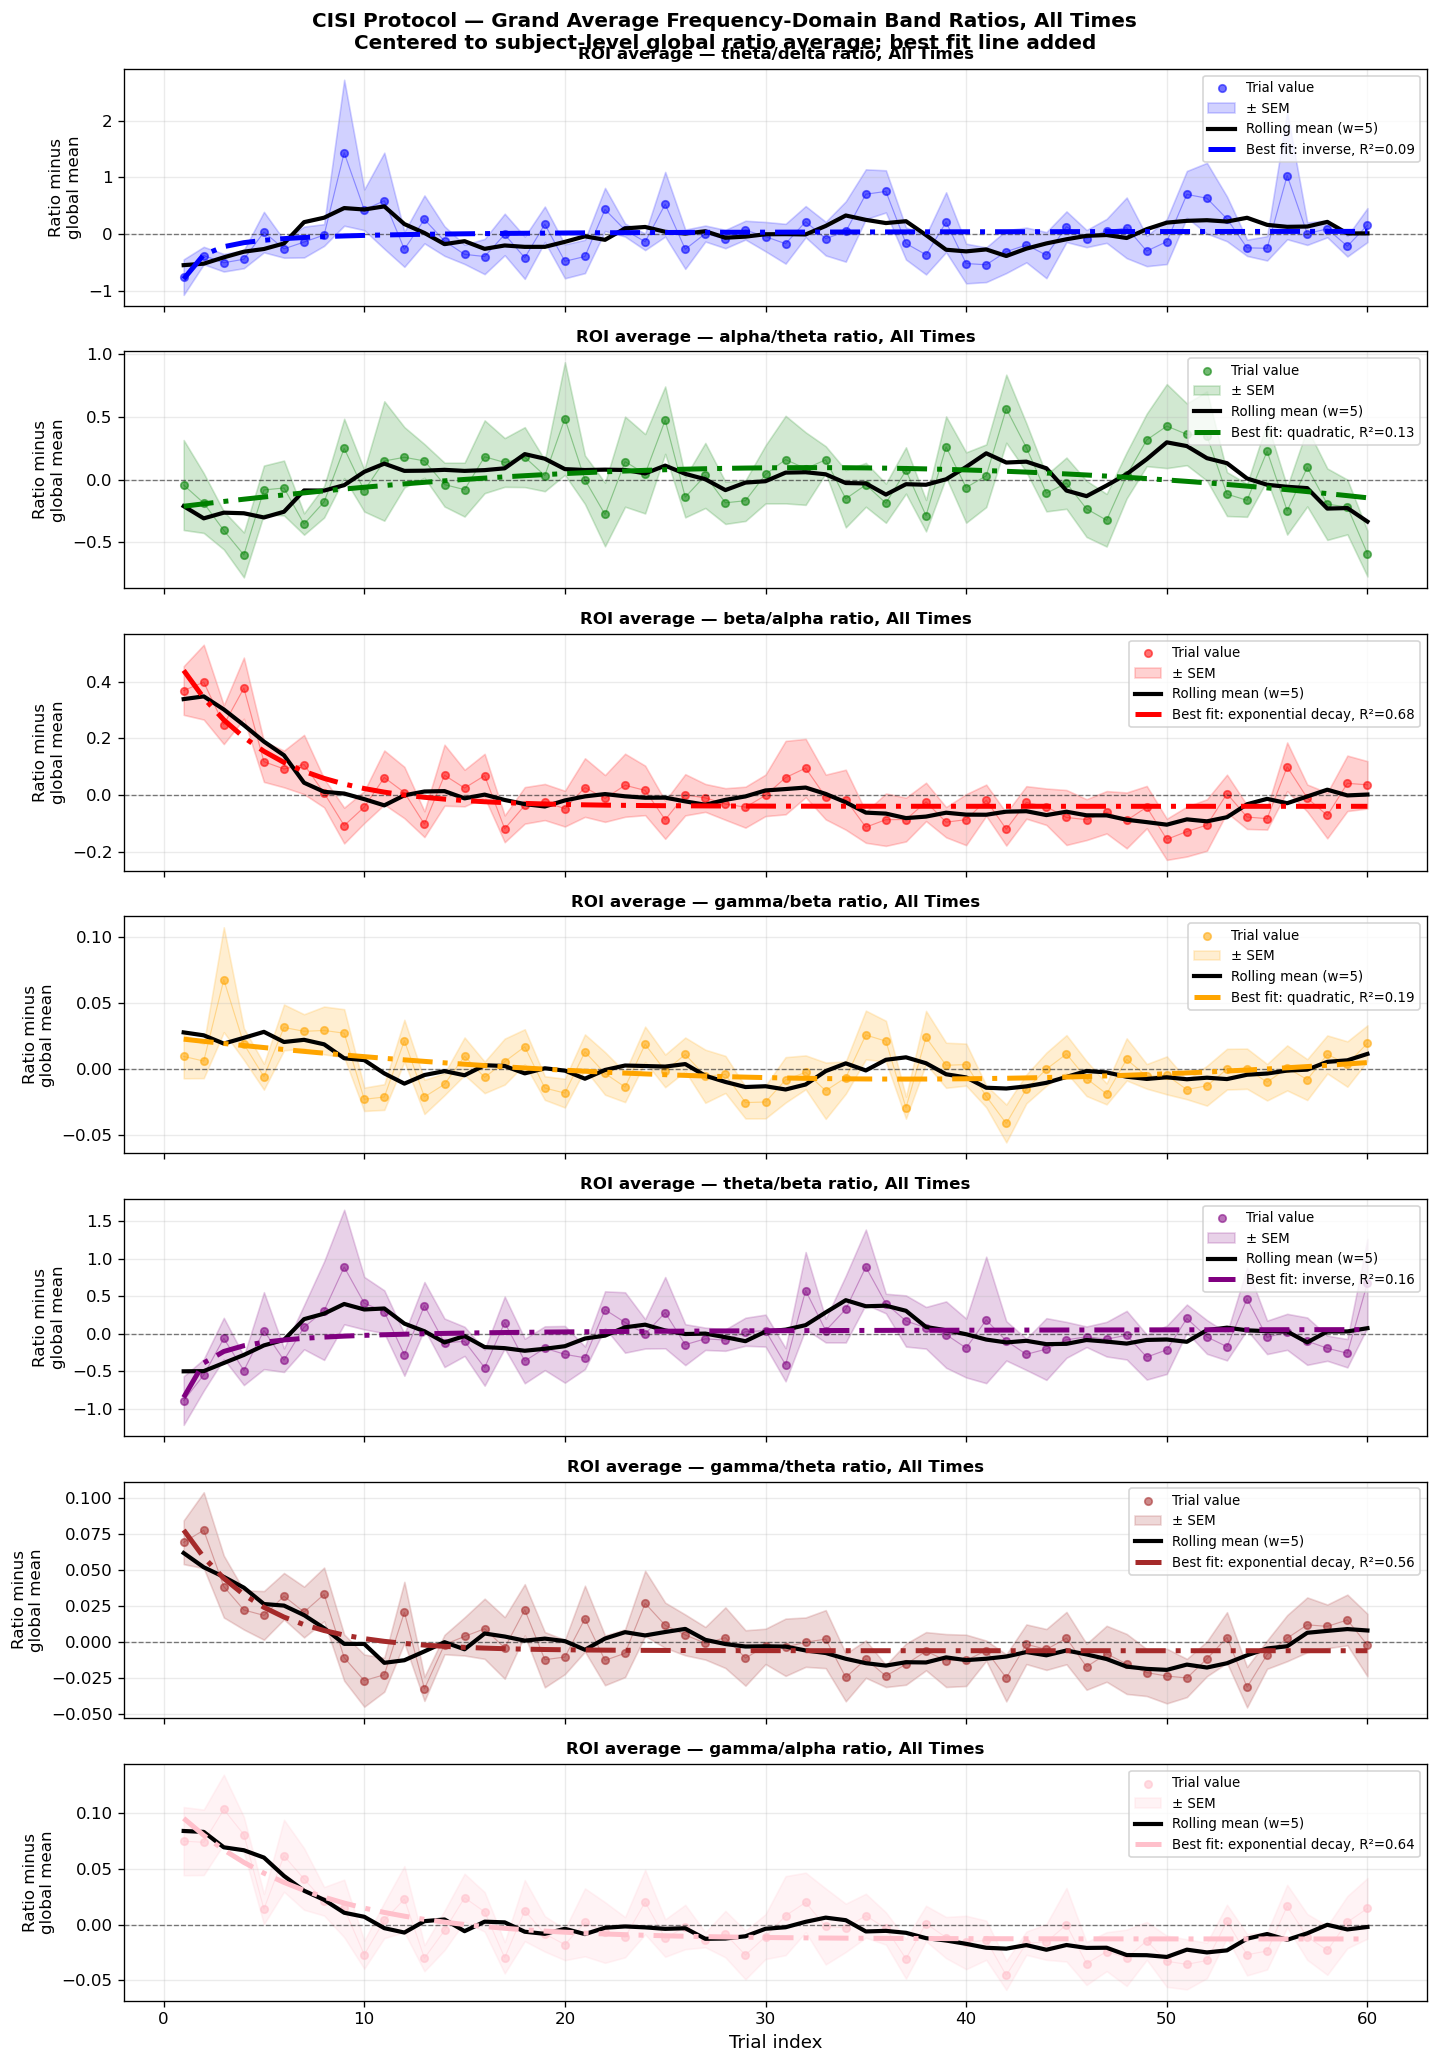

Figure saved: BLT_band_ratios_all_times_global_mean_centered.png
CISI band-ratio fit comparison — All Times


,Graph,Fit type,R squared,RMSE,AIC,Best by AIC
7,P1 ratio — alpha/theta (All Times),quadratic,0.125334,0.229114,-170.824141,True
8,P1 ratio — alpha/theta (All Times),cubic,0.125474,0.229096,-168.833781,False
11,P1 ratio — alpha/theta (All Times),exponential decay,0.089368,0.233777,-168.406356,False
9,P1 ratio — alpha/theta (All Times),logarithmic,0.041576,0.239833,-167.337286,False
10,P1 ratio — alpha/theta (All Times),inverse,0.036055,0.240523,-166.992633,False
6,P1 ratio — alpha/theta (All Times),linear,0.006564,0.244175,-165.184513,False
17,P1 ratio — beta/alpha (All Times),exponential decay,0.682989,0.064578,-322.786273,True
16,P1 ratio — beta/alpha (All Times),inverse,0.561576,0.075944,-305.331356,False
15,P1 ratio — beta/alpha (All Times),logarithmic,0.553016,0.076682,-304.171154,False
14,P1 ratio — beta/alpha (All Times),cubic,0.563289,0.075795,-301.566248,False


,Graph,Fit type,R squared,RMSE,AIC,Best by AIC
7,P1 ratio — alpha/theta (All Times),quadratic,0.125334,0.229114,-170.824141,True
8,P1 ratio — alpha/theta (All Times),cubic,0.125474,0.229096,-168.833781,False
11,P1 ratio — alpha/theta (All Times),exponential decay,0.089368,0.233777,-168.406356,False
9,P1 ratio — alpha/theta (All Times),logarithmic,0.041576,0.239833,-167.337286,False
10,P1 ratio — alpha/theta (All Times),inverse,0.036055,0.240523,-166.992633,False
6,P1 ratio — alpha/theta (All Times),linear,0.006564,0.244175,-165.184513,False
17,P1 ratio — beta/alpha (All Times),exponential decay,0.682989,0.064578,-322.786273,True
16,P1 ratio — beta/alpha (All Times),inverse,0.561576,0.075944,-305.331356,False
15,P1 ratio — beta/alpha (All Times),logarithmic,0.553016,0.076682,-304.171154,False
14,P1 ratio — beta/alpha (All Times),cubic,0.563289,0.075795,-301.566248,False


In [22]:
# Source: ZBLT_ratio(3).ipynb, cell 4

# ------------------------------------------------------------
# BAND RATIOS — ALL TIMES
# ------------------------------------------------------------

ratio_results_all_times = compute_centered_band_ratios_for_window(
    window_name="all_times",
    tmin=None,
    tmax=None
)

plot_centered_band_ratios(
    results=ratio_results_all_times,
    title_label="All Times",
    save_filename="BLT_band_ratios_all_times_global_mean_centered.png"
)





## CISI — Frequency-domain relative power

In [15]:
# Source: ZCISI_global.ipynb, cell 1

# NumPy handles arrays, indexing, and mathematical operations.
import numpy as np

# Pandas stores trial-by-band tables and makes averaging easier.
import pandas as pd

# Matplotlib is used to make the figures.
import matplotlib.pyplot as plt

# These imports let us silence extra warnings / printouts from the helper functions.
import warnings
import contextlib
import io

# These project helper functions are already used elsewhere in your notebook.
# - load_eeg_data loads the epochs for one subject
# - compute_frequency_power computes frequency-domain band power per trial
from utils import load_eeg_data, compute_frequency_power

# Show plots directly inside the notebook.
%matplotlib inline

# Slightly increase default display quality so the plots are easier to read.
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})





In [16]:
# Source: ZCISI_global.ipynb, cell 2

# These are the subjects used in your CISI analysis.
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]

# CONDITION tells the loader which task / dataset to open.
# For CISI, the working notebook loads the data using the P1 condition label.
CONDITION = "P1"

# CHANNELS tells the loader which ROI channel group to use.
# For CISI, the working notebook also uses the P1 channel label.
CHANNELS = "P1"

# These are the frequency bands that will be plotted in the final figure.
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

# These colors are only for plotting so each band has a consistent visual identity.
colors = ['blue', 'green', 'red', 'orange', 'purple']

# The rolling window is only for the thick black trend line.
# It smooths the visual trend but does NOT alter the stored trial values.
ROLLING_WINDOW = 5

# This label is just text for titles / print statements so you remember
# what kind of baseline this notebook is using.
BASELINE_LABEL = "global average over all times and all trials"

print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")
print(f"Baseline definition: {BASELINE_LABEL}")





Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: P1
Channels: P1
Baseline definition: global average over all times and all trials


In [17]:
# Source: ZCISI_global.ipynb, cell 3
# Safety imports so this cell still works if the import cell was not run first.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import contextlib
import io
from utils import load_eeg_data, compute_frequency_power


# These dictionaries store the trial-level outputs for each subject.
# all_power_pivots_raw[subject_id]
#     Raw absolute power for each trial and band before centering.
#
# all_global_baseline_pivots[subject_id]
#     One-row table containing the subject's across-trial mean power
#     for each band. This is the baseline that gets subtracted.
#
# all_power_pivots_centered[subject_id]
#     Raw trial power minus that subject's global band-wise baseline.
#
# all_psds_dicts[subject_id]
#     Extra PSD output returned by compute_frequency_power, saved in case
#     you want to inspect it later.
all_power_pivots_raw = {}
all_global_baseline_pivots = {}
all_power_pivots_centered = {}
all_psds_dicts = {}

# Keep track of which subjects processed successfully.
processed_subjects = []

# Keep track of failures so the notebook does not crash on one bad subject.
failed_subjects = []

# Loop over subjects one at a time so we can compute each subject's trial-level power.
for subject_id in SUBJECTS:
    try:
        # Silence extra warnings and console spam so the notebook output stays clean.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                # Load the epoched CISI data for this subject.
                epochs = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band="delta_gamma"
                )

                # Compute frequency-domain absolute power across the full epoch ("all times").
                # The helper returns:
                # - power_df: a long-format table with columns like trial, band, power
                # - psds_dict: extra PSD information saved for reference
                power_df, psds_dict = compute_frequency_power(epochs, fmin=0.5, fmax=45)

        # Convert the long-format power table into a trial x band matrix.
        #
        # groupby(['trial', 'band'])['power'].mean()
        #     If there are multiple rows per trial-band pair, average them first.
        #
        # unstack()
        #     Move the band labels out into separate columns.
        #
        # reindex(columns=bands)
        #     Force a consistent column order: delta, theta, alpha, beta, gamma.
        power_pivot_raw = (
            power_df.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        # Compute the global baseline for this subject.
        #
        # power_pivot_raw.mean(axis=0)
        #     Average DOWN the rows, so for each band we get one number:
        #     the mean power across ALL trials for that subject.
        #
        # This is the key change in this notebook.
        # We are NOT using a pre-stimulus crop anymore.
        # We are using the average full-epoch power across all trials.
        global_baseline = power_pivot_raw.mean(axis=0)

        # Turn that Series into a 1-row DataFrame so it is easy to inspect later.
        # The single row represents the subject's band-wise baseline values.
        global_baseline_pivot = pd.DataFrame([global_baseline], columns=bands)

        # Center each trial by subtracting the same band-specific baseline value.
        #
        # Because pandas aligns by column name, each trial's delta value gets
        # delta's baseline subtracted, alpha gets alpha's baseline subtracted, etc.
        power_pivot_centered = power_pivot_raw - global_baseline

        # Save everything for later plotting.
        all_power_pivots_raw[subject_id] = power_pivot_raw
        all_global_baseline_pivots[subject_id] = global_baseline_pivot
        all_power_pivots_centered[subject_id] = power_pivot_centered
        all_psds_dicts[subject_id] = psds_dict

        # Record that this subject finished successfully.
        processed_subjects.append(subject_id)

    except Exception as e:
        # Save the error message rather than stopping the whole notebook.
        failed_subjects.append((subject_id, str(e)))

print("Processed successfully:", processed_subjects)

if failed_subjects:
    print("\nFailed:")
    for subject_id, err in failed_subjects:
        print(f"Subject {subject_id}: {err}")





Processed successfully: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


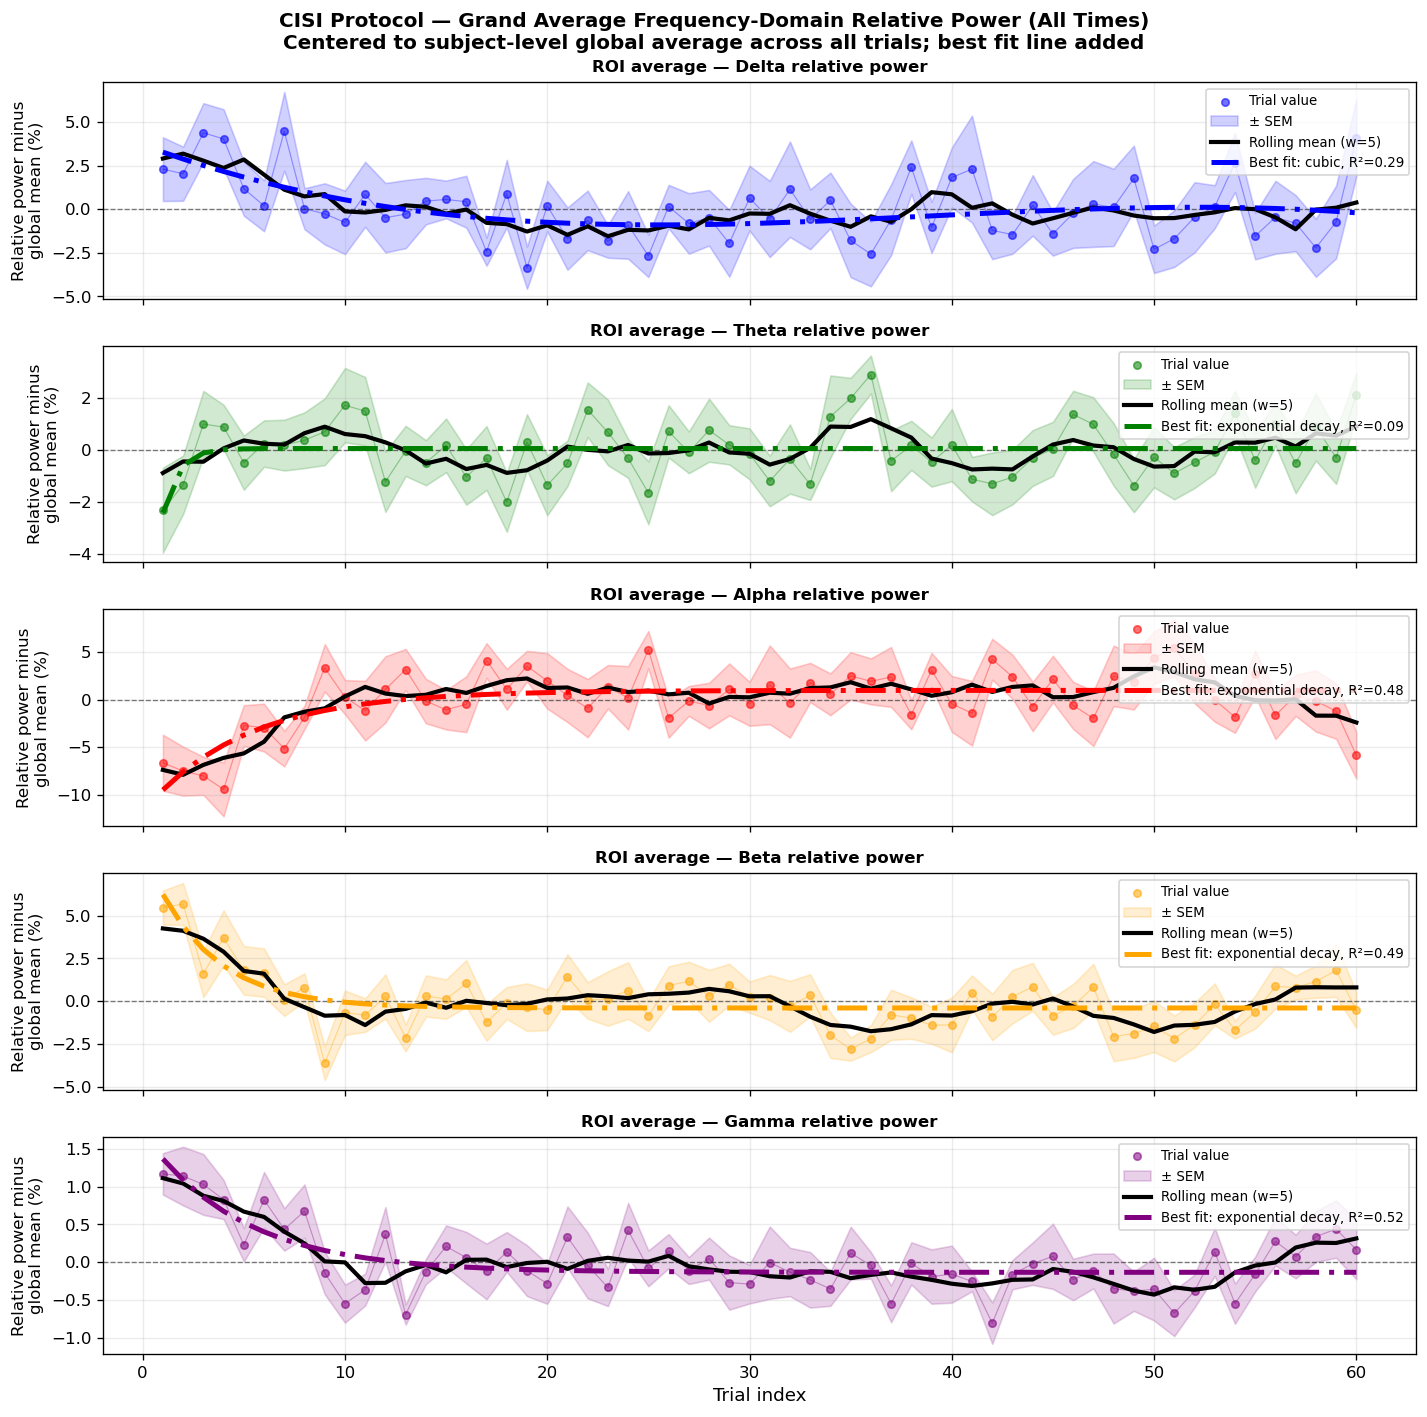

Figure saved: frequency_relative_dynamics_CISI_global_mean_centered.png
P1 frequency-domain relative power fit comparison


,Graph,Fit type,R squared,RMSE,AIC,Best by AIC
17,P1 relative power — alpha,exponential decay,0.476664,2.248177,103.214372,True
14,P1 relative power — alpha,cubic,0.449367,2.306063,108.265011,False
13,P1 relative power — alpha,quadratic,0.417058,2.372755,109.686190,False
16,P1 relative power — alpha,inverse,0.330035,2.543702,116.034477,False
15,P1 relative power — alpha,logarithmic,0.324366,2.554441,116.540012,False
12,P1 relative power — alpha,linear,0.123852,2.908900,132.133013,False
23,P1 relative power — beta,exponential decay,0.493054,1.182213,26.086596,True
22,P1 relative power — beta,inverse,0.438018,1.244734,30.270610,False
21,P1 relative power — beta,logarithmic,0.328029,1.361101,40.995273,False
19,P1 relative power — beta,quadratic,0.307540,1.381696,44.797378,False


In [18]:
# Source: ZCISI_global.ipynb, cell 11
# ------------------------------------------------------------
# FREQUENCY-DOMAIN RELATIVE POWER (all times)
# centered to a subject-level global relative-power mean
# ------------------------------------------------------------

# These dictionaries will store, for each subject:
# 1) the raw relative power for each trial and band
# 2) the one-row global baseline that gets subtracted
# 3) the centered relative power after subtracting that baseline
all_relative_power_pivots_raw = {}
all_relative_global_baseline_pivots = {}
all_relative_power_pivots_centered = {}

# Loop over each subject that already successfully completed
# the raw frequency-domain absolute-power section above.
for subject_id in processed_subjects:

    # Start from the raw absolute power table:
    # rows = trials
    # columns = bands
    power_pivot_raw = all_power_pivots_raw[subject_id].copy()

    # Force the same band order for every subject so later
    # averaging lines up delta with delta, alpha with alpha, etc.
    power_pivot_raw = power_pivot_raw.reindex(columns=bands)

    # For each trial, total power is the sum across all bands.
    # axis=1 means sum across columns within each row.
    total_power_per_trial = power_pivot_raw.sum(axis=1)

    # Convert absolute power into relative power:
    # each band becomes its percentage of that trial's total power.
    relative_power_raw = power_pivot_raw.div(total_power_per_trial, axis=0) * 100

    # Compute one subject-level global baseline for each band.
    # This is the mean relative power across all trials for that band.
    relative_global_baseline = relative_power_raw.mean(axis=0)

    # Save the baseline as a one-row DataFrame so you can inspect it later.
    relative_global_baseline_pivot = pd.DataFrame([relative_global_baseline], columns=bands)

    # Subtract the same baseline value from every trial in that band.
    # After this step:
    #   0  = equal to subject's average relative power for that band
    #   >0 = above average
    #   <0 = below average
    relative_power_centered = relative_power_raw - relative_global_baseline

    # Store everything.
    all_relative_power_pivots_raw[subject_id] = relative_power_raw
    all_relative_global_baseline_pivots[subject_id] = relative_global_baseline_pivot
    all_relative_power_pivots_centered[subject_id] = relative_power_centered

# These will hold the grand mean and SEM across subjects for each band.
grand_relative_power = {}
grand_relative_sem = {}

# Build one grand-average trial series per band.
for band in bands:

    # Collect one subject vector per band.
    band_trials = []

    for subject_id in processed_subjects:
        relative_pivot = all_relative_power_pivots_centered[subject_id]

        if band in relative_pivot.columns:
            # reset_index(drop=True) makes trial positions line up cleanly
            # when subjects are concatenated side by side.
            band_trials.append(relative_pivot[band].reset_index(drop=True))

    if band_trials:
        band_df = pd.concat(band_trials, axis=1)
        grand_relative_power[band] = band_df.mean(axis=1)
        grand_relative_sem[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

# Store fit-comparison results for each band in this graph.
all_fit_results = []

# Plot one subplot per band.
fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    if band in grand_relative_power:
        values = grand_relative_power[band].values
        errors = grand_relative_sem[band].values
        trial_idx = np.arange(1, len(values) + 1)

        # Trial-by-trial grand mean
        ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

        # Uncertainty shading
        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM'
        )

        # Rolling trend line to make the overall direction easier to see
        rolling = pd.Series(values).rolling(
            window=ROLLING_WINDOW,
            center=True,
            min_periods=1
        ).mean()

        ax.plot(
            trial_idx,
            rolling,
            color='black',
            linewidth=2.5,
            zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})'
        )

        # Test multiple fit types and add the best fit line.
        # The rolling mean stays black; the best fit uses a dash-dot colored line.
        add_best_fit_to_axis(
            ax=ax,
            trial_idx=trial_idx,
            values=values,
            line_color=color,
            label_prefix=f"{CONDITION} relative power — {band}",
            all_fit_results=all_fit_results
        )

    ax.set_ylabel('Relative power minus\nglobal mean (%)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} relative power', fontsize=10, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.25)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Trial index', fontsize=11)

fig.suptitle(
    'CISI Protocol — Grand Average Frequency-Domain Relative Power (All Times)\n'
    'Centered to subject-level global average across all trials; best fit line added',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('frequency_relative_dynamics_CISI_global_mean_centered.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: frequency_relative_dynamics_CISI_global_mean_centered.png")

# Show the fit-comparison table for this figure.
fit_results_df = display_fit_table(
    all_fit_results,
    title=f"{CONDITION} frequency-domain relative power fit comparison"
)






## CISI — Band ratios

In [19]:
# Source: ZCISI_ratio.ipynb, cell 2

# These are the subjects used in your CISI analysis.
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]

# CONDITION tells the loader which task / dataset to open.
# For CISI, the working notebook loads the data using the P1 condition label.
CONDITION = "P1"

# CHANNELS tells the loader which ROI channel group to use.
# For CISI, the working notebook also uses the P1 channel label.
CHANNELS = "P1"

# These are the frequency bands that will be plotted in the final figure.
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

# These colors are only for plotting so each band has a consistent visual identity.
colors = ['blue', 'green', 'red', 'orange', 'purple']

# The rolling window is only for the thick black trend line.
# It smooths the visual trend but does NOT alter the stored trial values.
ROLLING_WINDOW = 5

# This label is just text for titles / print statements so you remember
# what kind of baseline this notebook is using.
BASELINE_LABEL = "global average over all times and all trials"

print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")
print(f"Baseline definition: {BASELINE_LABEL}")


# ------------------------------------------------------------
# BAND RATIO SETTINGS
# ------------------------------------------------------------

# Each tuple is written as:
#     ('numerator_band', 'denominator_band')
#
# Example:
#     ('theta', 'alpha') means theta power divided by alpha power.
#
# You can edit this list if you want different pairs.
BAND_RATIO_PAIRS = [
    ('theta', 'delta'),
    ('alpha', 'theta'),
    ('beta', 'alpha'),
    ('gamma', 'beta'),
    ('theta', 'beta'),
    ('gamma', 'theta'),
    ('gamma', 'alpha')
]

# These labels will be used on the plots.
ratio_labels = [f"{num}/{den}" for num, den in BAND_RATIO_PAIRS]

# Colors for ratio plots. If there are more ratios than colors, the list repeats.
ratio_colors = [
    'blue',
    'green',
    'red',
    'orange',
    'purple',
    'brown',
    'pink',
    'gray',
    'olive',
    'cyan'
]

print("Band ratio pairs:")
for pair in BAND_RATIO_PAIRS:
    print(f"  {pair[0]} / {pair[1]}")





Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: P1
Channels: P1
Baseline definition: global average over all times and all trials
Band ratio pairs:
  theta / delta
  alpha / theta
  beta / alpha
  gamma / beta
  theta / beta
  gamma / theta
  gamma / alpha


In [20]:
# Source: ZCISI_ratio.ipynb, cell 3
# Safety imports so this cell still works if the import cell was not run first.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import contextlib
import io
from utils import load_eeg_data, compute_frequency_power


# ------------------------------------------------------------
# HELPER FUNCTION: COMPUTE CENTERED BAND RATIOS
# ------------------------------------------------------------

def compute_centered_band_ratios_for_window(window_name, tmin=None, tmax=None):
    """
    Computes centered frequency-band ratios for one time window.

    Parameters
    ----------
    window_name : str
        Text label for the window, such as "all_times", "0_500", or "500_1000".

    tmin : float or None
        Start time in seconds.
        Use None to keep the original beginning of the epoch.

    tmax : float or None
        End time in seconds.
        Use None to keep the original end of the epoch.

    Returns
    -------
    results : dict
        A dictionary containing raw ratio tables, baseline ratio tables,
        centered ratio tables, grand averages, SEMs, processed subjects,
        and failed subjects.
    """

    # These dictionaries store subject-level results.
    all_power_pivots_raw = {}
    all_ratio_pivots_raw = {}
    all_ratio_baseline_pivots = {}
    all_ratio_pivots_centered = {}
    all_psds_dicts = {}

    processed_subjects_window = []
    failed_subjects_window = []

    # Loop through each subject.
    for subject_id in SUBJECTS:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                    # Load the same CISI/P1 epochs as the original notebook.
                    epochs = load_eeg_data(
                        CONDITION,
                        subject_id,
                        channels=CHANNELS,
                        freq_band="delta_gamma"
                    )

                    # Crop only if a time window was given.
                    # MNE uses seconds, so:
                    #   0–500 ms      = tmin=0.0, tmax=0.5
                    #   500–1000 ms   = tmin=0.5, tmax=1.0
                    if tmin is not None or tmax is not None:
                        epochs_for_ratio = epochs.copy().crop(tmin=tmin, tmax=tmax)
                    else:
                        epochs_for_ratio = epochs.copy()

                    # Compute frequency-domain absolute power using the same helper function.
                    power_df, psds_dict = compute_frequency_power(
                        epochs_for_ratio,
                        fmin=0.5,
                        fmax=45
                    )

            # Convert long-format power output into trial x band format.
            power_pivot_raw = (
                power_df.groupby(['trial', 'band'])['power']
                .mean()
                .unstack()
                .reindex(columns=bands)
            )

            # This table will hold ratio values for each trial.
            ratio_pivot_raw = pd.DataFrame(index=power_pivot_raw.index)

            # Compute each requested band ratio.
            for numerator_band, denominator_band in BAND_RATIO_PAIRS:

                ratio_name = f"{numerator_band}/{denominator_band}"

                # Make sure both bands exist before computing the ratio.
                if numerator_band in power_pivot_raw.columns and denominator_band in power_pivot_raw.columns:

                    # Ratio = power in numerator band / power in denominator band.
                    ratio_pivot_raw[ratio_name] = (
                        power_pivot_raw[numerator_band] / power_pivot_raw[denominator_band]
                    )

                else:
                    # If a band is missing, fill with NaN so the notebook does not crash.
                    ratio_pivot_raw[ratio_name] = np.nan

            # Replace infinite values with NaN, just in case a denominator is zero.
            ratio_pivot_raw = ratio_pivot_raw.replace([np.inf, -np.inf], np.nan)

            # Compute this subject's global mean ratio across all trials.
            ratio_global_baseline = ratio_pivot_raw.mean(axis=0)

            # Center each trial by subtracting this subject's global mean ratio.
            ratio_pivot_centered = ratio_pivot_raw - ratio_global_baseline

            # Store subject-level outputs.
            all_power_pivots_raw[subject_id] = power_pivot_raw
            all_ratio_pivots_raw[subject_id] = ratio_pivot_raw
            all_ratio_baseline_pivots[subject_id] = pd.DataFrame(
                [ratio_global_baseline],
                columns=ratio_pivot_raw.columns
            )
            all_ratio_pivots_centered[subject_id] = ratio_pivot_centered
            all_psds_dicts[subject_id] = psds_dict

            processed_subjects_window.append(subject_id)

        except Exception as e:
            failed_subjects_window.append((subject_id, str(e)))

    print(f"{window_name} ratio subjects processed:", processed_subjects_window)

    if failed_subjects_window:
        print(f"\n{window_name} ratio failures:")
        for subject_id, err in failed_subjects_window:
            print(f"Subject {subject_id}: {err}")

    # Grand average across subjects.
    grand_ratio = {}
    grand_ratio_sem = {}

    for ratio_name in ratio_labels:
        ratio_trials = []

        for subject_id in processed_subjects_window:
            ratio_pivot = all_ratio_pivots_centered[subject_id]

            if ratio_name in ratio_pivot.columns:
                ratio_trials.append(ratio_pivot[ratio_name].reset_index(drop=True))

        if ratio_trials:
            ratio_df = pd.concat(ratio_trials, axis=1)

            # Mean across subjects at each trial index.
            grand_ratio[ratio_name] = ratio_df.mean(axis=1)

            # SEM across subjects at each trial index.
            grand_ratio_sem[ratio_name] = ratio_df.std(axis=1) / np.sqrt(ratio_df.shape[1])

    return {
        "window_name": window_name,
        "tmin": tmin,
        "tmax": tmax,
        "all_power_pivots_raw": all_power_pivots_raw,
        "all_ratio_pivots_raw": all_ratio_pivots_raw,
        "all_ratio_baseline_pivots": all_ratio_baseline_pivots,
        "all_ratio_pivots_centered": all_ratio_pivots_centered,
        "all_psds_dicts": all_psds_dicts,
        "processed_subjects": processed_subjects_window,
        "failed_subjects": failed_subjects_window,
        "grand_ratio": grand_ratio,
        "grand_ratio_sem": grand_ratio_sem
    }


# ------------------------------------------------------------
# HELPER FUNCTION: PLOT CENTERED BAND RATIOS
# ------------------------------------------------------------

def plot_centered_band_ratios(results, title_label, save_filename):
    """
    Plots the grand-average centered ratio values for one time window.
    Adds rolling mean in black and tests multiple fit types for each ratio.
    """

    grand_ratio = results["grand_ratio"]
    grand_ratio_sem = results["grand_ratio_sem"]

    # Store fit-comparison results for each ratio in this graph.
    all_fit_results = []

    # Create one subplot per ratio.
    fig, axes = plt.subplots(len(ratio_labels), 1, figsize=(12, 2.5 * len(ratio_labels)), sharex=True)

    # If there is only one ratio, axes is not automatically a list.
    if len(ratio_labels) == 1:
        axes = [axes]

    for i, ratio_name in enumerate(ratio_labels):
        ax = axes[i]
        color = ratio_colors[i % len(ratio_colors)]

        if ratio_name in grand_ratio:
            values = grand_ratio[ratio_name].values
            errors = grand_ratio_sem[ratio_name].values
            trial_idx = np.arange(1, len(values) + 1)

            ax.scatter(
                trial_idx,
                values,
                color=color,
                s=20,
                alpha=0.55,
                zorder=2,
                label='Trial value'
            )

            ax.plot(
                trial_idx,
                values,
                color=color,
                linewidth=0.7,
                alpha=0.35,
                zorder=1
            )

            ax.fill_between(
                trial_idx,
                values - errors,
                values + errors,
                color=color,
                alpha=0.18,
                zorder=1,
                label='± SEM'
            )

            # Rolling mean stays black.
            rolling = pd.Series(values).rolling(
                window=ROLLING_WINDOW,
                center=True,
                min_periods=1
            ).mean()

            ax.plot(
                trial_idx,
                rolling,
                color='black',
                linewidth=2.5,
                zorder=3,
                label=f'Rolling mean (w={ROLLING_WINDOW})'
            )

            # Test multiple fit types and add the best fit line.
            # The fit line is dash-dot so it looks different from the rolling mean.
            add_best_fit_to_axis(
                ax=ax,
                trial_idx=trial_idx,
                values=values,
                line_color=color,
                label_prefix=f"{CONDITION} ratio — {ratio_name} ({title_label})",
                all_fit_results=all_fit_results
            )

        ax.set_ylabel('Ratio minus\nglobal mean', fontsize=10)

        ax.set_title(
            f'ROI average — {ratio_name} ratio, {title_label}',
            fontsize=10,
            fontweight='bold'
        )

        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.25)
        ax.legend(loc='upper right', fontsize=8)

    axes[-1].set_xlabel('Trial index', fontsize=11)

    fig.suptitle(
        f'CISI Protocol — Grand Average Frequency-Domain Band Ratios, {title_label}\n'
        f'Centered to subject-level global ratio average; best fit line added',
        fontsize=12,
        fontweight='bold'
    )

    fig.tight_layout()
    plt.savefig(save_filename, bbox_inches='tight', dpi=150)
    plt.show()

    print(f"Figure saved: {save_filename}")

    # Show the fit-comparison table for this ratio figure.
    fit_results_df = display_fit_table(
        all_fit_results,
        title=f"CISI band-ratio fit comparison — {title_label}"
    )

    return fit_results_df






all_times ratio subjects processed: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


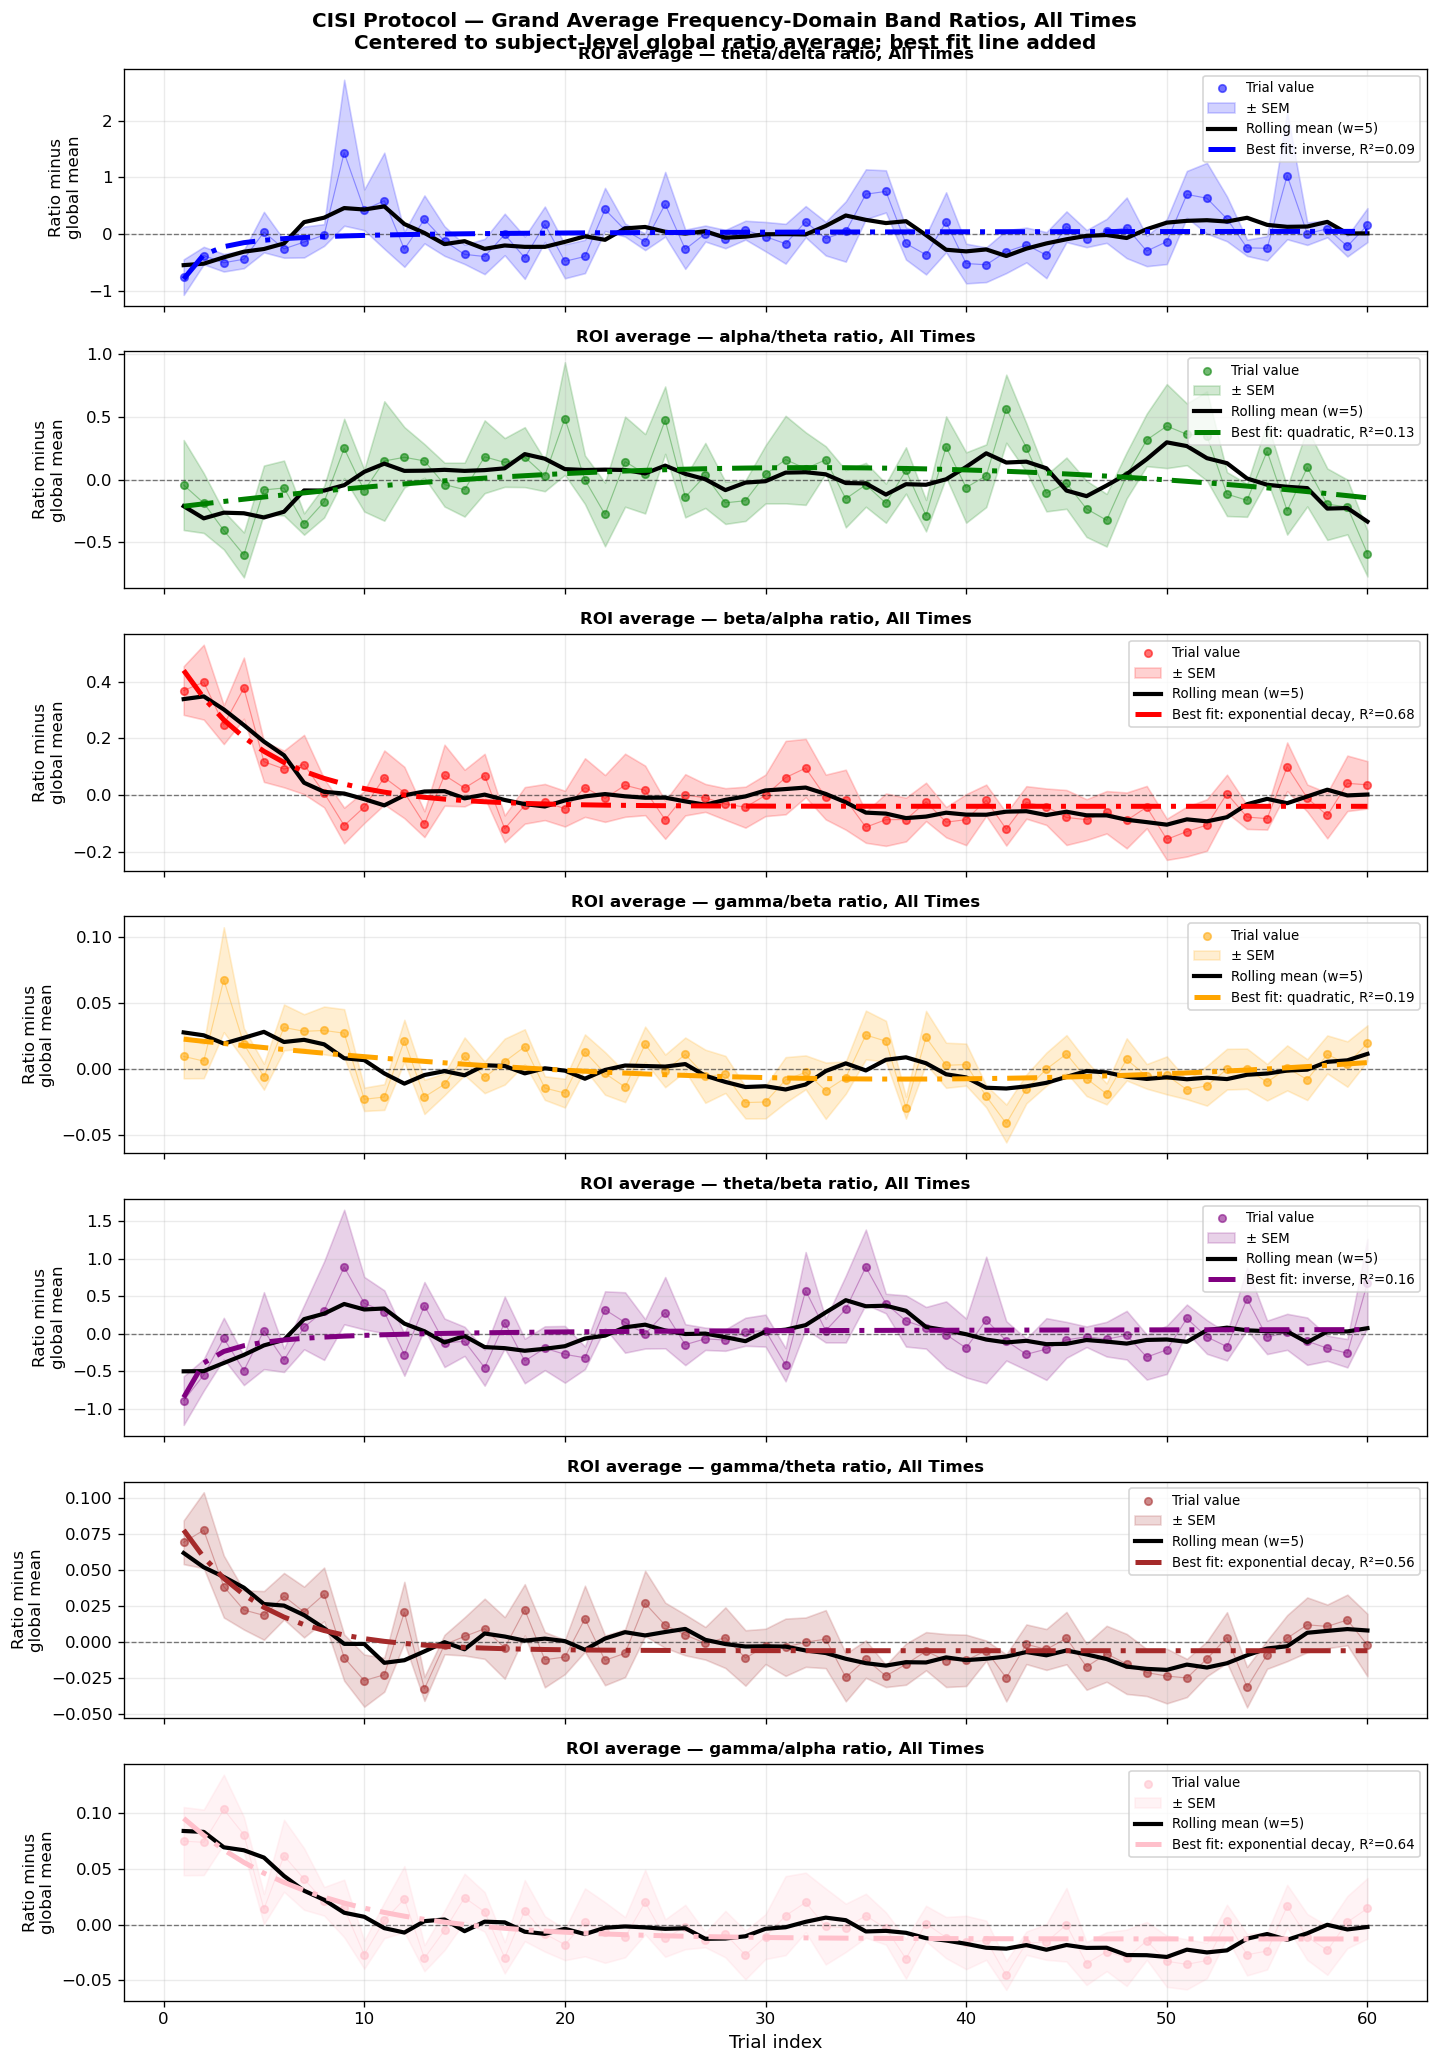

Figure saved: CISI_band_ratios_all_times_global_mean_centered.png
CISI band-ratio fit comparison — All Times


,Graph,Fit type,R squared,RMSE,AIC,Best by AIC
7,P1 ratio — alpha/theta (All Times),quadratic,0.125334,0.229114,-170.824141,True
8,P1 ratio — alpha/theta (All Times),cubic,0.125474,0.229096,-168.833781,False
11,P1 ratio — alpha/theta (All Times),exponential decay,0.089368,0.233777,-168.406356,False
9,P1 ratio — alpha/theta (All Times),logarithmic,0.041576,0.239833,-167.337286,False
10,P1 ratio — alpha/theta (All Times),inverse,0.036055,0.240523,-166.992633,False
6,P1 ratio — alpha/theta (All Times),linear,0.006564,0.244175,-165.184513,False
17,P1 ratio — beta/alpha (All Times),exponential decay,0.682989,0.064578,-322.786273,True
16,P1 ratio — beta/alpha (All Times),inverse,0.561576,0.075944,-305.331356,False
15,P1 ratio — beta/alpha (All Times),logarithmic,0.553016,0.076682,-304.171154,False
14,P1 ratio — beta/alpha (All Times),cubic,0.563289,0.075795,-301.566248,False


,Graph,Fit type,R squared,RMSE,AIC,Best by AIC
7,P1 ratio — alpha/theta (All Times),quadratic,0.125334,0.229114,-170.824141,True
8,P1 ratio — alpha/theta (All Times),cubic,0.125474,0.229096,-168.833781,False
11,P1 ratio — alpha/theta (All Times),exponential decay,0.089368,0.233777,-168.406356,False
9,P1 ratio — alpha/theta (All Times),logarithmic,0.041576,0.239833,-167.337286,False
10,P1 ratio — alpha/theta (All Times),inverse,0.036055,0.240523,-166.992633,False
6,P1 ratio — alpha/theta (All Times),linear,0.006564,0.244175,-165.184513,False
17,P1 ratio — beta/alpha (All Times),exponential decay,0.682989,0.064578,-322.786273,True
16,P1 ratio — beta/alpha (All Times),inverse,0.561576,0.075944,-305.331356,False
15,P1 ratio — beta/alpha (All Times),logarithmic,0.553016,0.076682,-304.171154,False
14,P1 ratio — beta/alpha (All Times),cubic,0.563289,0.075795,-301.566248,False


In [21]:
# Source: ZCISI_ratio.ipynb, cell 4

# ------------------------------------------------------------
# BAND RATIOS — ALL TIMES
# ------------------------------------------------------------

ratio_results_all_times = compute_centered_band_ratios_for_window(
    window_name="all_times",
    tmin=None,
    tmax=None
)

plot_centered_band_ratios(
    results=ratio_results_all_times,
    title_label="All Times",
    save_filename="CISI_band_ratios_all_times_global_mean_centered.png"
)



